# Introduction to Machine Learning in R
### A Practical Guide for Spatial Analysis and Mapping

---

> *"In God we trust. All others must bring data."*
> — W. Edwards Deming

---

In this section we introduce the fundamental concepts of machine learning, with a focus on applications that are relevant to spatial analysis, remote sensing, and ecological mapping. By the end of this section, you should get an understanding on **how** to build machine learning models in R and **why** each decision in the workflow matters. 

This notebook introduces the fundamental concepts of machine learning with a focus on applications
relevant to spatial analysis, remote sensing, and ecological mapping. Every concept is paired with
working R code and publication-quality visualisations. By the end of this notebook you will understand
not only **how** to build machine learning models in R, but **why** each decision in the workflow matters —
from data preparation through to model validation.

## Topics covered

we will be covering the following topics:

1. What is Machine Learning?
2. Supervised vs Unsupervised Learning
3. The General ML Workflow
4. Why Data Matters More Than Models
5. Which Model Should You Choose?
6. Model Building in R
7. Model Validation and Testing
8. Visualising Results

## R Packages required:

```r
install.packages(c("tidyverse", "tidymodels", "ranger", "xgboost",
                   "kernlab", "kknn", "factoextra", "cluster",
                   "vip", "DALEXtra", "patchwork", "showtext",
                   "ggridges", "corrplot", "yardstick", "rpart.plot"))
```

### Libraries and themes

We begin by loading all required packages and making a consistent visual theme that will be used across all figures.

In [2]:
# Load libraries
library(tidyverse)
library(tidymodels)
library(ranger)
library(xgboost)
library(kernlab)
library(kknn)
library(factoextra)
library(cluster)
library(vip)
library(patchwork)
library(showtext)
library(ggridges)
library(scales)
library(glmnet)
library(rpart)
library(rpart.plot)

In [3]:
# Add elegant fonts
font_add_google("Playfair Display", "playfair")
font_add_google("Montserrat",       "mont")
font_add_google("Fira Code",        "fira")
showtext_auto()

In [4]:
# Add plot dimensions
options(
  repr.plot.width  = 14,
  repr.plot.height = 8,
  repr.plot.res    = 180
)

# Increase timeout to 10 minutes (600 seconds)
options(timeout = 600)

In [5]:
# Add {ggplot2} themes
theme_ml <- function(base_size = 11) {
  theme_minimal(base_family = "mont", base_size = base_size) +
  theme(
    plot.background   = element_rect(fill = "#fafafa", colour = NA),
    panel.background  = element_rect(fill = "#ffffff", colour = NA),
    panel.grid.major  = element_line(colour = "#eeeeee", linewidth = 0.4),
    panel.grid.minor  = element_blank(),
    panel.border      = element_rect(colour = "#dddddd", fill = NA,
                                     linewidth = 0.5),
    plot.title        = element_text(family = "playfair", face = "bold",
                                     size   = base_size * 1.6,
                                     colour = "#1a1a2e",
                                     margin = margin(b = 6)),
    plot.subtitle     = element_text(size   = base_size * 0.95,
                                     colour = "#4a4a6a",
                                     margin = margin(b = 10)),
    plot.caption      = element_text(size   = base_size * 0.72,
                                     colour = "#9a9ab0", hjust = 0,
                                     margin = margin(t = 10)),
    axis.title        = element_text(colour = "#1a1a2e", size = base_size * 0.9,
                                     face = "bold"),
    axis.text         = element_text(colour = "#5a5a7a", size = base_size * 0.82),
    legend.position   = "bottom",
    legend.title      = element_text(face = "bold", colour = "#1a1a2e",
                                     size = base_size * 0.85),
    legend.text       = element_text(colour = "#4a4a6a", size = base_size * 0.8),
    strip.background  = element_rect(fill = "#1a1a2e", colour = NA),
    strip.text        = element_text(colour = "white", face = "bold",
                                     size = base_size * 0.85),
    plot.margin       = margin(16, 20, 12, 16)
  )
}

In [6]:
# Add colour palettes
PalDiscrete  <- c("#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#6c5ce7")
PalDiverging <- c("#2166ac", "#92c5de", "#f7f7f7", "#f4a582", "#d6604d")
PalSequential <- c("#fff9f0", "#fdd49e", "#fdbb84", "#fc8d59", "#d7301f", "#7f0000")

## 1 · What is Machine Learning?

So far we have used models to describe data but a lot of times we might want to create a model that is able to predict new data. This may be new data outside of our temporal or spatial range, or outside of our current knowledge base. The best set of tools for predicting new data is generally Machine Learning (ML) methods.

Machine learning is the practice of teaching computers to learn patterns from data without being explicitly programmed with rules. Instead of a programmer writing `if temperature > 30 then hot`, a machine learning algorithm examines thousands of examples and **learns** what combination of variables predicts the outcome.

### The three questions ML answers:

| Question | ML Task | Example in Spatial Analysis |
|----------|---------|----------------------------|
| What class does this belong to? | **Classification** | Is this pixel fynbos, urban, or water? |
| What value will this be? | **Regression** | What is the biomass of this forest plot? |
| What groups exist in this data? | **Clustering** | What spectral communities exist in this scene? |

### Why ML for spatial analysis?

Traditional remote sensing relied on hand-crafted spectral indices (NDVI, NDBI etc.) — rules written by experts. Machine learning replaces or augments these rules by learning the relationship between spectral bands and the target variable directly from labelled examples. This is especially powerful for:

- **Hyperspectral data** with hundreds of bands where manual rule-writing is impossible
- **Complex landscapes** where simple thresholds fail
- **Species distribution modelling** across environmental gradients
- **Change detection** across multi-temporal imagery

For a pretty full and comprehensive discussion, with advantages and disadvantages go here: https://ml-science-book.com

In [7]:
# Visualise the three ML paradigms
set.seed(42)
n <- 300

# Classification data — two separable groups with noise
ClassData <- tibble(
  x     = c(rnorm(n/2, 2, 0.8), rnorm(n/2, 5, 0.8)),
  y     = c(rnorm(n/2, 2, 0.8), rnorm(n/2, 5, 0.8)),
  class = factor(rep(c("Fynbos", "Urban"), each = n/2))
)

# Regression data — continuous relationship
RegData <- tibble(
  x    = seq(0, 10, length.out = n),
  y    = 2.5 * x + rnorm(n, 0, 2.5) + sin(x) * 3,
  pred = 2.5 * seq(0, 10, length.out = n) + sin(seq(0,10,length.out=n)) * 3
)

# Clustering data — unlabelled groups
ClustData <- tibble(
  x = c(rnorm(100, 1, 0.5), rnorm(100, 4, 0.5), rnorm(100, 2.5, 0.5)),
  y = c(rnorm(100, 1, 0.5), rnorm(100, 1, 0.5), rnorm(100, 4, 0.5))
)
km <- kmeans(ClustData, centers = 3)
ClustData$cluster <- factor(km$cluster)

In [8]:
# Build panels
P1 <- ggplot(ClassData, aes(x, y, colour = class)) +
  geom_point(size = 1.8, alpha = 0.7) +
  stat_ellipse(linewidth = 1, linetype = "dashed") +
  scale_colour_manual(values = c(PalDiscrete[1], PalDiscrete[2]),
                      name = "Land Cover") +
  labs(title    = "Classification",
       subtitle = "Predicting which category a pixel belongs to",
       x = "Band 4 (NIR)", y = "Band 3 (Red)") +
  theme_ml()

P2 <- ggplot(RegData, aes(x, y)) +
  geom_point(colour = PalDiscrete[3], size = 1.5, alpha = 0.6) +
  geom_line(aes(y = pred), colour = "#1a1a2e", linewidth = 1.2) +
  labs(title    = "Regression",
       subtitle = "Predicting a continuous value from input features",
       x = "Canopy Cover (%)", y = "Above-ground Biomass (t/ha)") +
  theme_ml()

P3 <- ggplot(ClustData, aes(x, y, colour = cluster)) +
  geom_point(size = 1.8, alpha = 0.7) +
  scale_colour_manual(values = PalDiscrete[c(1,2,3)], name = "Cluster") +
  labs(title    = "Clustering",
       subtitle = "Discovering hidden groups without labels",
       x = "Principal Component 1", y = "Principal Component 2") +
  theme_ml()

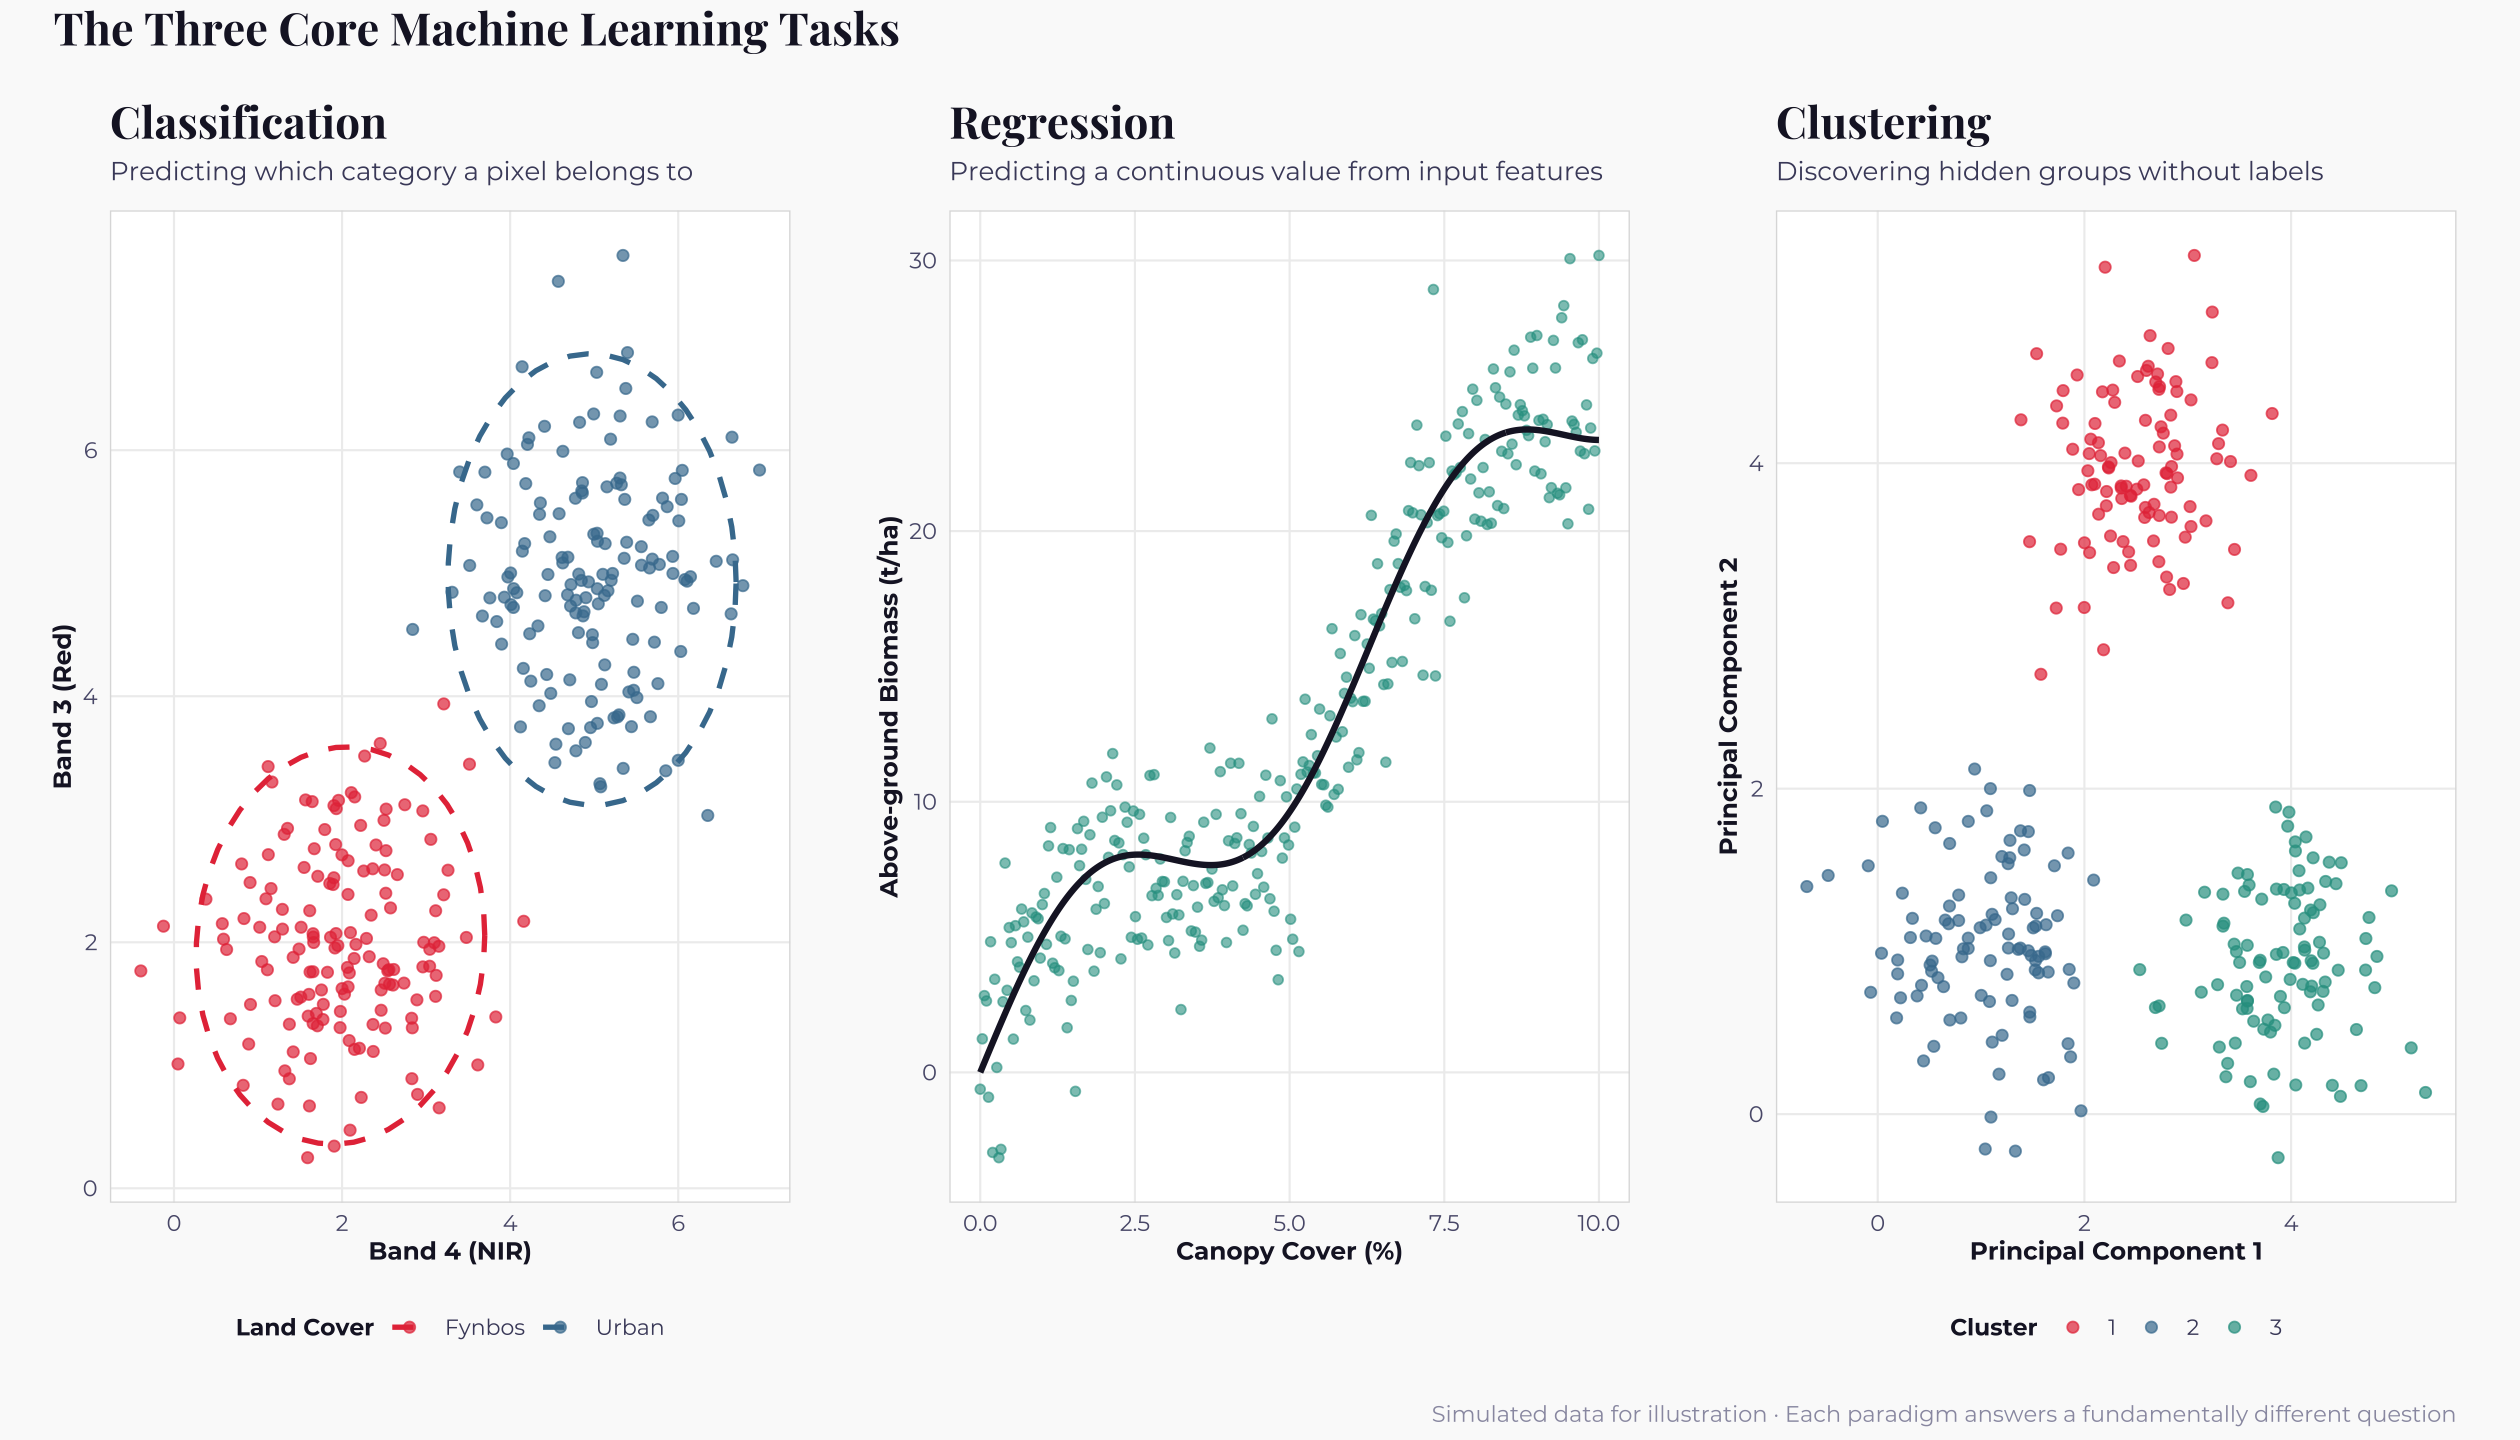

In [9]:
(P1 | P2 | P3) +
  plot_annotation(
    title   = "The Three Core Machine Learning Tasks",
    caption = "Simulated data for illustration · Each paradigm answers a fundamentally different question",
    theme   = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 18, colour = "#1a1a2e"),
      plot.caption    = element_text(family = "mont", size = 9,
                                     colour = "#9a9ab0")
    )
  )

## 2 · Supervised vs Unsupervised Learning

The most fundamental division in machine learning is whether your data has **labels** or not.

### Supervised Learning

Supervised learning algorithms or models are models where we ‘train’ a model with known and labelled data so that the model can discern patterns that when it is given unknown/unlabelled data it will be able to, hopefully, predict what the label should be. These models can perform both regression (continuous data) or classification (categorical data), but will be highly reliant on the data used to train the model, as values or classes outside of what it has already seen will have much higher inaccuracy.

**Requires:** Ground truth labels (field surveys, digitised training polygons, sensor measurements)

**Examples:** Random Forest land cover classification, Support Vector Machine species mapping, Gradient Boosting biomass regression

### Unsupervised Learning

Unsupervised learning algorithms or models are one group of ML models that require minimum input. Usupervised models do not require training/labelled data and thus require less initial work. These methods will group similar data into groups or clusters. Since the vast majority of data is unlabelled, Unsupervised models appeal in that they can be applied with no prior work. However, the user will normally define how many groups to split the data into or at what level of similarity to split, and thus may influence the model itself. Generally, these methods are poor at complex prediction tasks and can be easily outperformed by Supervised ML.

**Requires:** Only the feature data itself — no labels needed

**Examples:** K-means spectral clustering, PCA dimensionality reduction, ISODATA classification

### Semi-supervised Learning

A practical middle ground — a small number of labelled examples combined with a large pool of unlabelled data. This is very relevant for remote sensing where field campaigns are expensive.

In [10]:
# Illutrate the Supervised vs Unsupervised decision boundary
set.seed(123)
n <- 200

# Supervised — labelled points with a decision boundary
SupData <- tibble(
  x1    = c(rnorm(n, 2, 1), rnorm(n, 5, 1)),
  x2    = c(rnorm(n, 3, 1), rnorm(n, 6, 1)),
  label = factor(rep(c("Class A
(Fynbos)", "Class B
(Forest)"), each = n))
)

In [11]:
# Fit logistic boundary for illustration
mod   <- glm(as.numeric(label) - 1 ~ x1 + x2, data = SupData, family = "binomial")
grid  <- expand.grid(x1 = seq(0, 8, 0.1), x2 = seq(0, 9, 0.1))
grid$prob <- predict(mod, grid, type = "response")

In [12]:
PSup <- ggplot() +
  geom_tile(data = grid, aes(x1, x2, fill = prob), alpha = 0.25) +
  scale_fill_gradientn(
    colours = c(PalDiscrete[2], "white", PalDiscrete[1]),
    limits  = c(0, 1), guide = "none"
  ) +
  geom_point(data = SupData,
             aes(x1, x2, colour = label),
             size = 1.5, alpha = 0.7) +
  scale_colour_manual(values = c(PalDiscrete[2], PalDiscrete[1]),
                      name = "Known Label") +
  labs(title    = "Supervised Learning",
       subtitle = "Algorithm learns decision boundary from labelled examples",
       x = "Feature 1", y = "Feature 2",
       caption  = "Shading = predicted probability surface") +
  theme_ml()

In [13]:
# Unsupervised — same data without labels, k-means clustering
UnsupData <- SupData %>% select(x1, x2)
km2       <- kmeans(UnsupData, centers = 2, nstart = 20)
UnsupData$cluster <- factor(km2$cluster)
centres   <- as_tibble(km2$centers) %>% mutate(cluster = factor(1:2))

In [14]:
PUnsup <- ggplot(UnsupData, aes(x1, x2, colour = cluster)) +
  geom_point(size = 1.5, alpha = 0.7) +
  geom_point(data = centres, aes(x1, x2),
             shape = 8, size = 6, colour = "#1a1a2e", stroke = 1.5) +
  scale_colour_manual(values = c(PalDiscrete[4], PalDiscrete[5]),
                      name = "Discovered Cluster") +
  labs(title    = "Unsupervised Learning",
       subtitle = "Algorithm discovers structure with no prior labels",
       x = "Feature 1", y = "Feature 2",
       caption  = "★ = cluster centroids · No label information provided") +
  theme_ml()

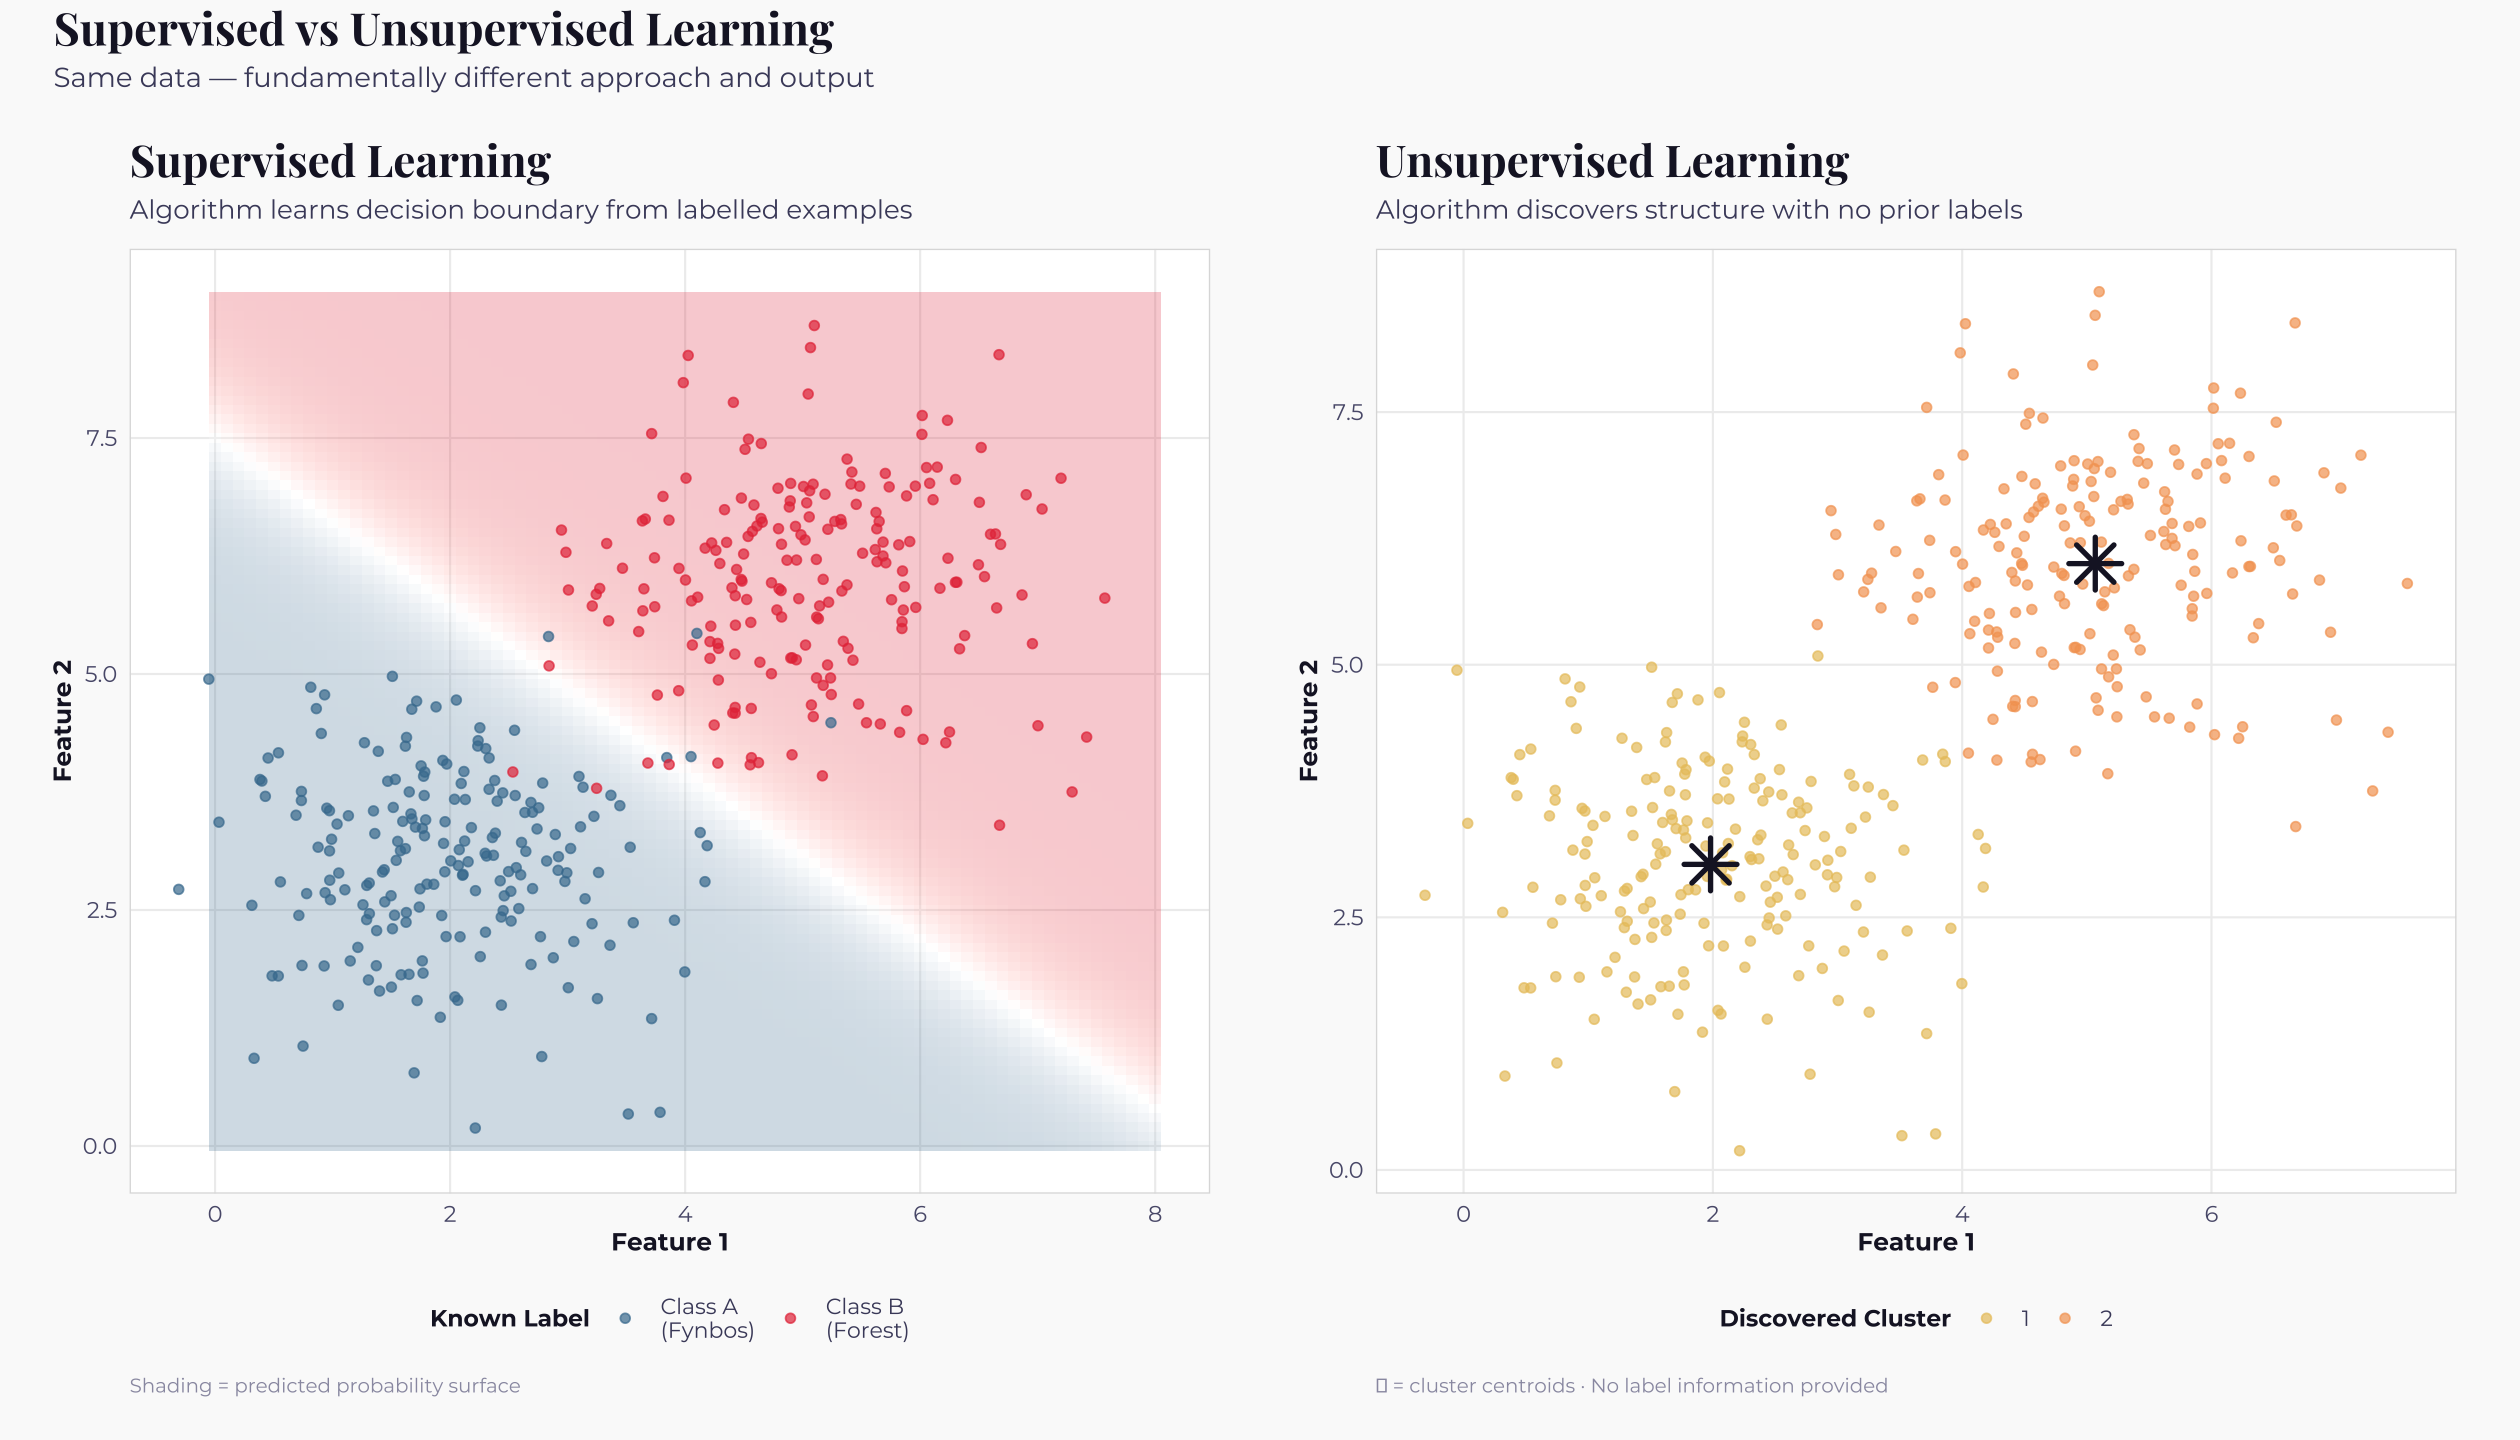

In [15]:
(PSup | PUnsup) +
  plot_annotation(
    title   = "Supervised vs Unsupervised Learning",
    subtitle = "Same data — fundamentally different approach and output",
    theme   = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 18, colour = "#1a1a2e"),
      plot.subtitle   = element_text(family = "mont", size = 11,
                                     colour = "#4a4a6a")
    )
  )

## 3· The General Machine Learning Workflow

Every machine learning project, regardless of the algorithm, follows the same fundamental sequence. Skipping or rushing any step produces unreliable results.

```
Raw Data
    │
    ▼
Data Collection & Exploration  ←── Understand your data before touching a model
    │
    ▼
Preprocessing & Feature Engineering  ←── The most important step
    │
    ▼
Train / Validation / Test Split  ←── Split data into training data*, testing data (ratios will vary but often 75/25)
    │
    ▼
Model Selection & Training  ←── Try multiple models
    │
    ▼
Hyperparameter Tuning  ←── Optimise on validation data, not test data
    │
    ▼
Final Evaluation on Test Set  ←── One time only — this is your honest estimate
    │
    ▼
Interpretation & Deployment
```

The training data are used to train a ML algorithm. The ML is applied to the testing data to predict what their label should be. The predicted label is compared to the true label of the testing data, and the accuracy of the model is calculated from the difference/similarity between the predicted and true labels.

*For higher accuracy and better model performance, the training data are often split again into folds (often cross validation folds) to repetitively repeat model training with different value elements termed hyper parameters (These are different tuning elements for each different type of model). The different hyper parameter values are used and accuracy is assess on each fold, then the ‘best’ performing hyper parameter values are selected for the model that is then used to predict on the testing data.

### The Golden Rule

**The test set must never influence any decision during model development.** Not preprocessing. Not feature selection. Not hyperparameter tuning. Nothing. Contaminating the test set with training information produces optimistically biased accuracy estimates that will not generalise to real-world data.

In [16]:
# Visualising the train/validation/test split
set.seed(42)

# Simulate a dataset of 1000 observations
n_total <- 1000
SplitVis <- tibble(
  obs    = 1:n_total,
  split  = case_when(
    obs <= 700         ~ "Training Set (70%)",
    obs <= 850         ~ "Validation Set (15%)",
    TRUE               ~ "Test Set (15%)"
  ),
  value  = rnorm(n_total, mean = rep(c(5, 4.8, 5.1), c(700, 150, 150)), sd = 1.5)
)

In [17]:
SplitVis$split <- factor(SplitVis$split,
  levels = c("Training Set (70%)", "Validation Set (15%)", "Test Set (15%)"))

SplitColours <- c(
  "Training Set (70%)"    = PalDiscrete[2],
  "Validation Set (15%)"  = PalDiscrete[4],
  "Test Set (15%)"        = PalDiscrete[1]
)

In [18]:
# Panel A — the split as a bar
PA <- ggplot(SplitVis, aes(x = obs, y = 1, fill = split)) +
  geom_tile(height = 0.5) +
  scale_fill_manual(values = SplitColours, name = NULL) +
  scale_x_continuous(
    breaks = c(350, 775, 925),
    labels = c("Training
n = 700", "Validation
n = 150", "Test
n = 150")
  ) +
  labs(title    = "Data Partitioning",
       subtitle = "How 1,000 observations are divided across the three sets") +
  theme_ml() +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    panel.grid   = element_blank(),
    legend.position = "none"
  )

In [19]:
# Panel B — distribution of values across splits (should be similar)
PB <- ggplot(SplitVis, aes(x = value, y = split, fill = split)) +
  geom_density_ridges(alpha = 0.75, scale = 0.9, colour = "white") +
  scale_fill_manual(values = SplitColours, guide = "none") +
  labs(title    = "Distribution Check",
       subtitle = "Feature distributions should be similar across all splits",
       x = "Feature Value", y = NULL) +
  theme_ml()

In [20]:
# Panel C — what each split is used for
UsageData <- tibble(
  split   = factor(c("Training", "Validation", "Test"),
                   levels = c("Training", "Validation", "Test")),
  purpose = c("Fit model parameters", "Tune hyperparameters
& compare models",
              "Final honest
accuracy estimate"),
  touched = c("Many times", "Many times", "ONCE — at the end"),
  colour  = c(PalDiscrete[2], PalDiscrete[4], PalDiscrete[1])
)

In [21]:
PC <- ggplot(UsageData, aes(x = split, y = 1, fill = split)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = purpose, y = 0.5),
            family = "mont", size = 3.5, colour = "white",
            fontface = "bold", lineheight = 0.9) +
  geom_text(aes(label = paste("Used:", touched), y = 1.05),
            family = "mont", size = 3, colour = "#1a1a2e") +
  scale_fill_manual(values = SplitColours) +
  scale_y_continuous(limits = c(0, 1.3)) +
  labs(title    = "Purpose of Each Split",
       subtitle = "Each partition serves a distinct role in the workflow",
       x = NULL, y = NULL) +
  theme_ml() +
  theme(axis.text.y = element_blank(), panel.grid = element_blank())

Picking joint bandwidth of 0.453

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


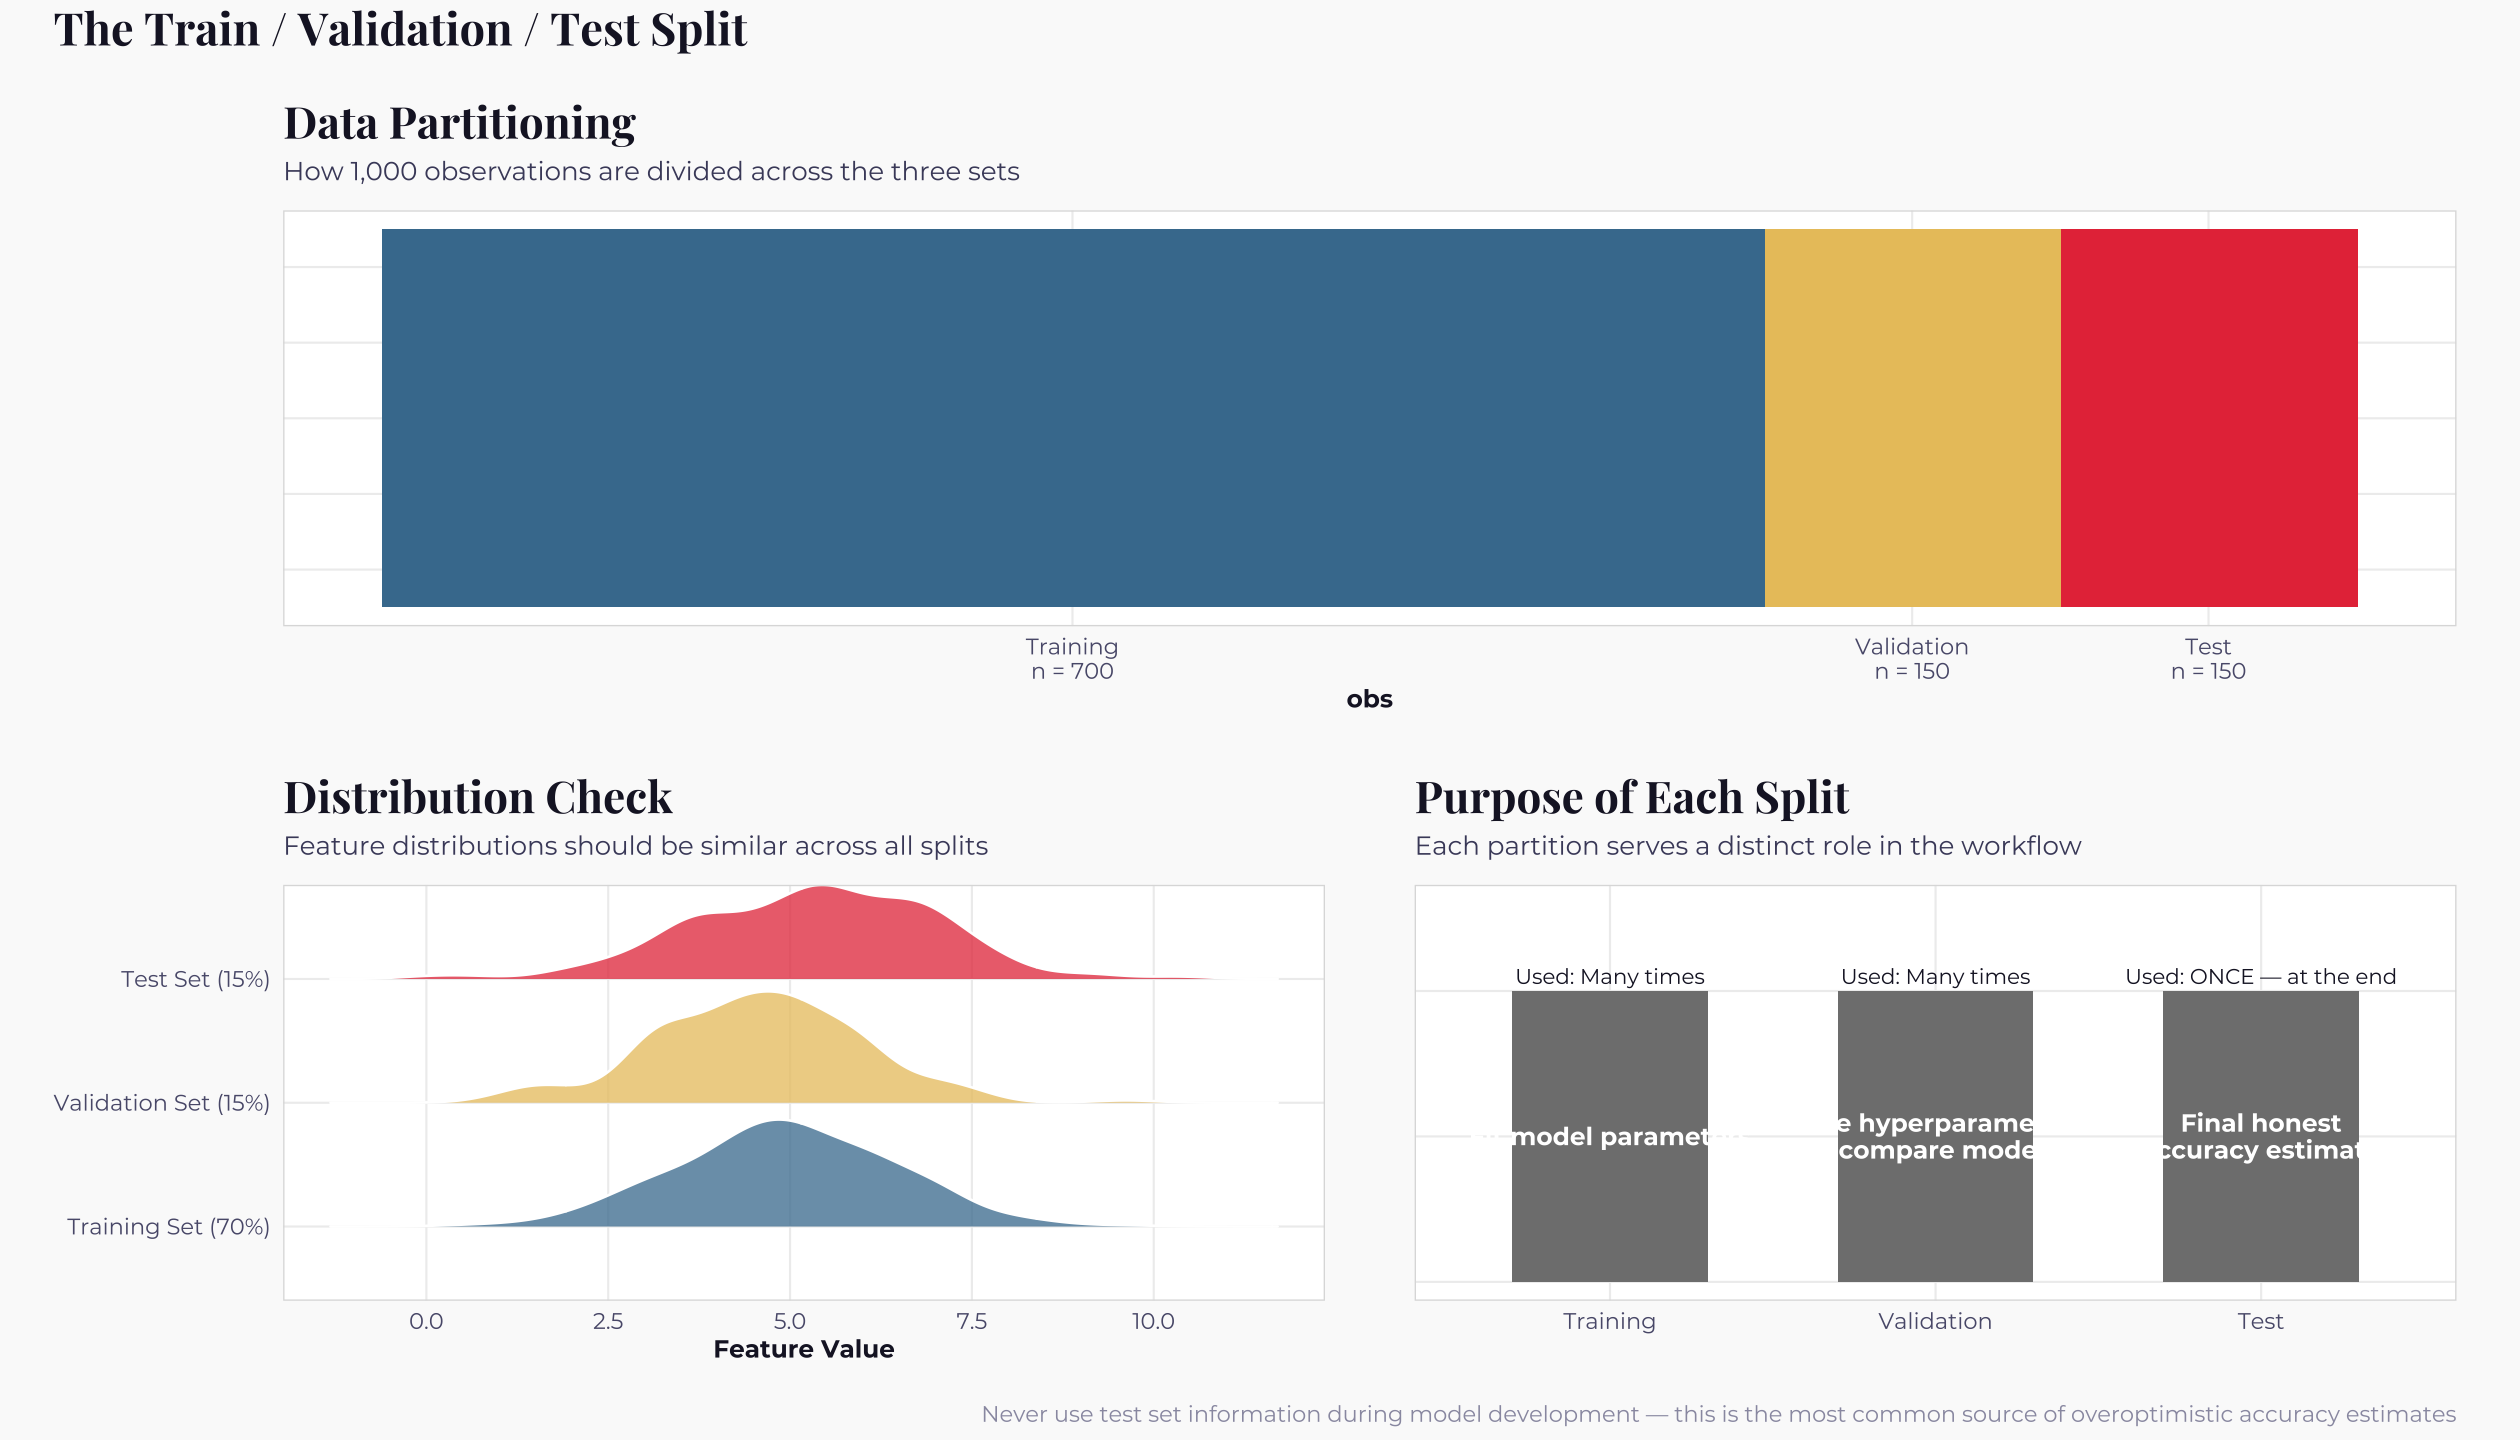

In [22]:
(PA / (PB | PC)) +
  plot_annotation(
    title   = "The Train / Validation / Test Split",
    caption = "Never use test set information during model development — this is the most common source of overoptimistic accuracy estimates",
    theme   = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 18, colour = "#1a1a2e"),
      plot.caption    = element_text(family = "mont", size = 9,
                                     colour = "#9a9ab0")
    )
  )

## 4 · Why Data Matters More Than Models

This is the most important conceptual lesson in machine learning and the one most often ignored by beginners who focus obsessively on choosing the "best" algorithm.

> *"Better data beats better algorithms. More data beats clever algorithms."*
> — Peter Norvig, Director of Research, Google

### The hierarchy of what matters:

1. **Data quality** — trash in, trash out. Mislabelled training data, positional errors in spatial data, or systematic sensor artefacts will degrade any model regardless of how sophisticated it is.

2. **Data quantity** — more representative samples consistently outperform algorithmic cleverness. A Random Forest trained on 10,000 well-distributed field samples will outperform an XGBoost model trained on 200 biased samples every time.

3. **Feature relevance** — are your input variables actually predictive of your target? 100 irrelevant bands degrade performance more than 10 informative ones.

4. **Class balance** — in land cover mapping, rare classes (wetlands, riparian vegetation) are consistently underclassified because the model sees 10,000 fynbos pixels for every 50 wetland pixels. The model learns to ignore the minority class.

5. **Spatial autocorrelation in splits** — this is the most overlooked problem in spatial ML. If your training and test pixels are spatially adjacent, accuracy is overestimated because nearby pixels are not independent observations.

6. **Algorithm choice** — matters least. A well-prepared dataset with a simple model almost always outperforms a poorly prepared dataset with a complex model.

In [23]:
# Demonstrating why data quality beats algorithm sophistication
set.seed(99)

# Scenario: mapping two vegetation types from spectral data
# We compare: clean data + simple model vs dirty data + complex model

n <- 500

In [24]:
# Clean dataset — well-labelled, representative sampling
CleanData <- tibble(
  band_nir  = c(rnorm(n/2, 0.6, 0.08), rnorm(n/2, 0.35, 0.08)),
  band_red  = c(rnorm(n/2, 0.1, 0.04), rnorm(n/2, 0.25, 0.06)),
  label     = factor(rep(c("Fynbos", "Renosterveld"), each = n/2))
)

# Dirty dataset — 20% label noise (mislabelled training points)
DirtyData <- CleanData %>%
  mutate(label = if_else(
    runif(n) < 0.20,
    factor(if_else(as.integer(label) == 1, 2L, 1L),
           levels = c("1","2"),
           labels = c("Fynbos","Renosterveld")),
    label
  ))

# Biased dataset — spatially clustered sampling (bad design)
BiasedData <- CleanData %>%
  slice(c(1:80, 251:330))  # only 160 samples, clustered at extremes

In [25]:
# Visualise the three data quality scenarios
plot_data_quality <- function(df, title, subtitle, highlight_noise = FALSE) {
  p <- ggplot(df, aes(band_nir, band_red, colour = label)) +
    geom_point(size = 1.8, alpha = 0.65) +
    scale_colour_manual(values = c(PalDiscrete[3], PalDiscrete[4]),
                        name = "Label") +
    scale_x_continuous(name = "NIR Reflectance", limits = c(0.1, 0.85)) +
    scale_y_continuous(name = "Red Reflectance", limits = c(0.0, 0.42)) +
    labs(title = title, subtitle = subtitle) +
    theme_ml(base_size = 10)
  p
}

In [26]:
PClean  <- plot_data_quality(CleanData,  "Clean Data",
  paste0("n = ", n, " · 0% label noise · representative sampling"))
PDirty  <- plot_data_quality(DirtyData,  "Noisy Labels",
  paste0("n = ", n, " · 20% label noise · same algorithm"))
PBiased <- plot_data_quality(BiasedData, "Biased Sampling",
  paste0("n = ", nrow(BiasedData), " · only extreme samples collected"))

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


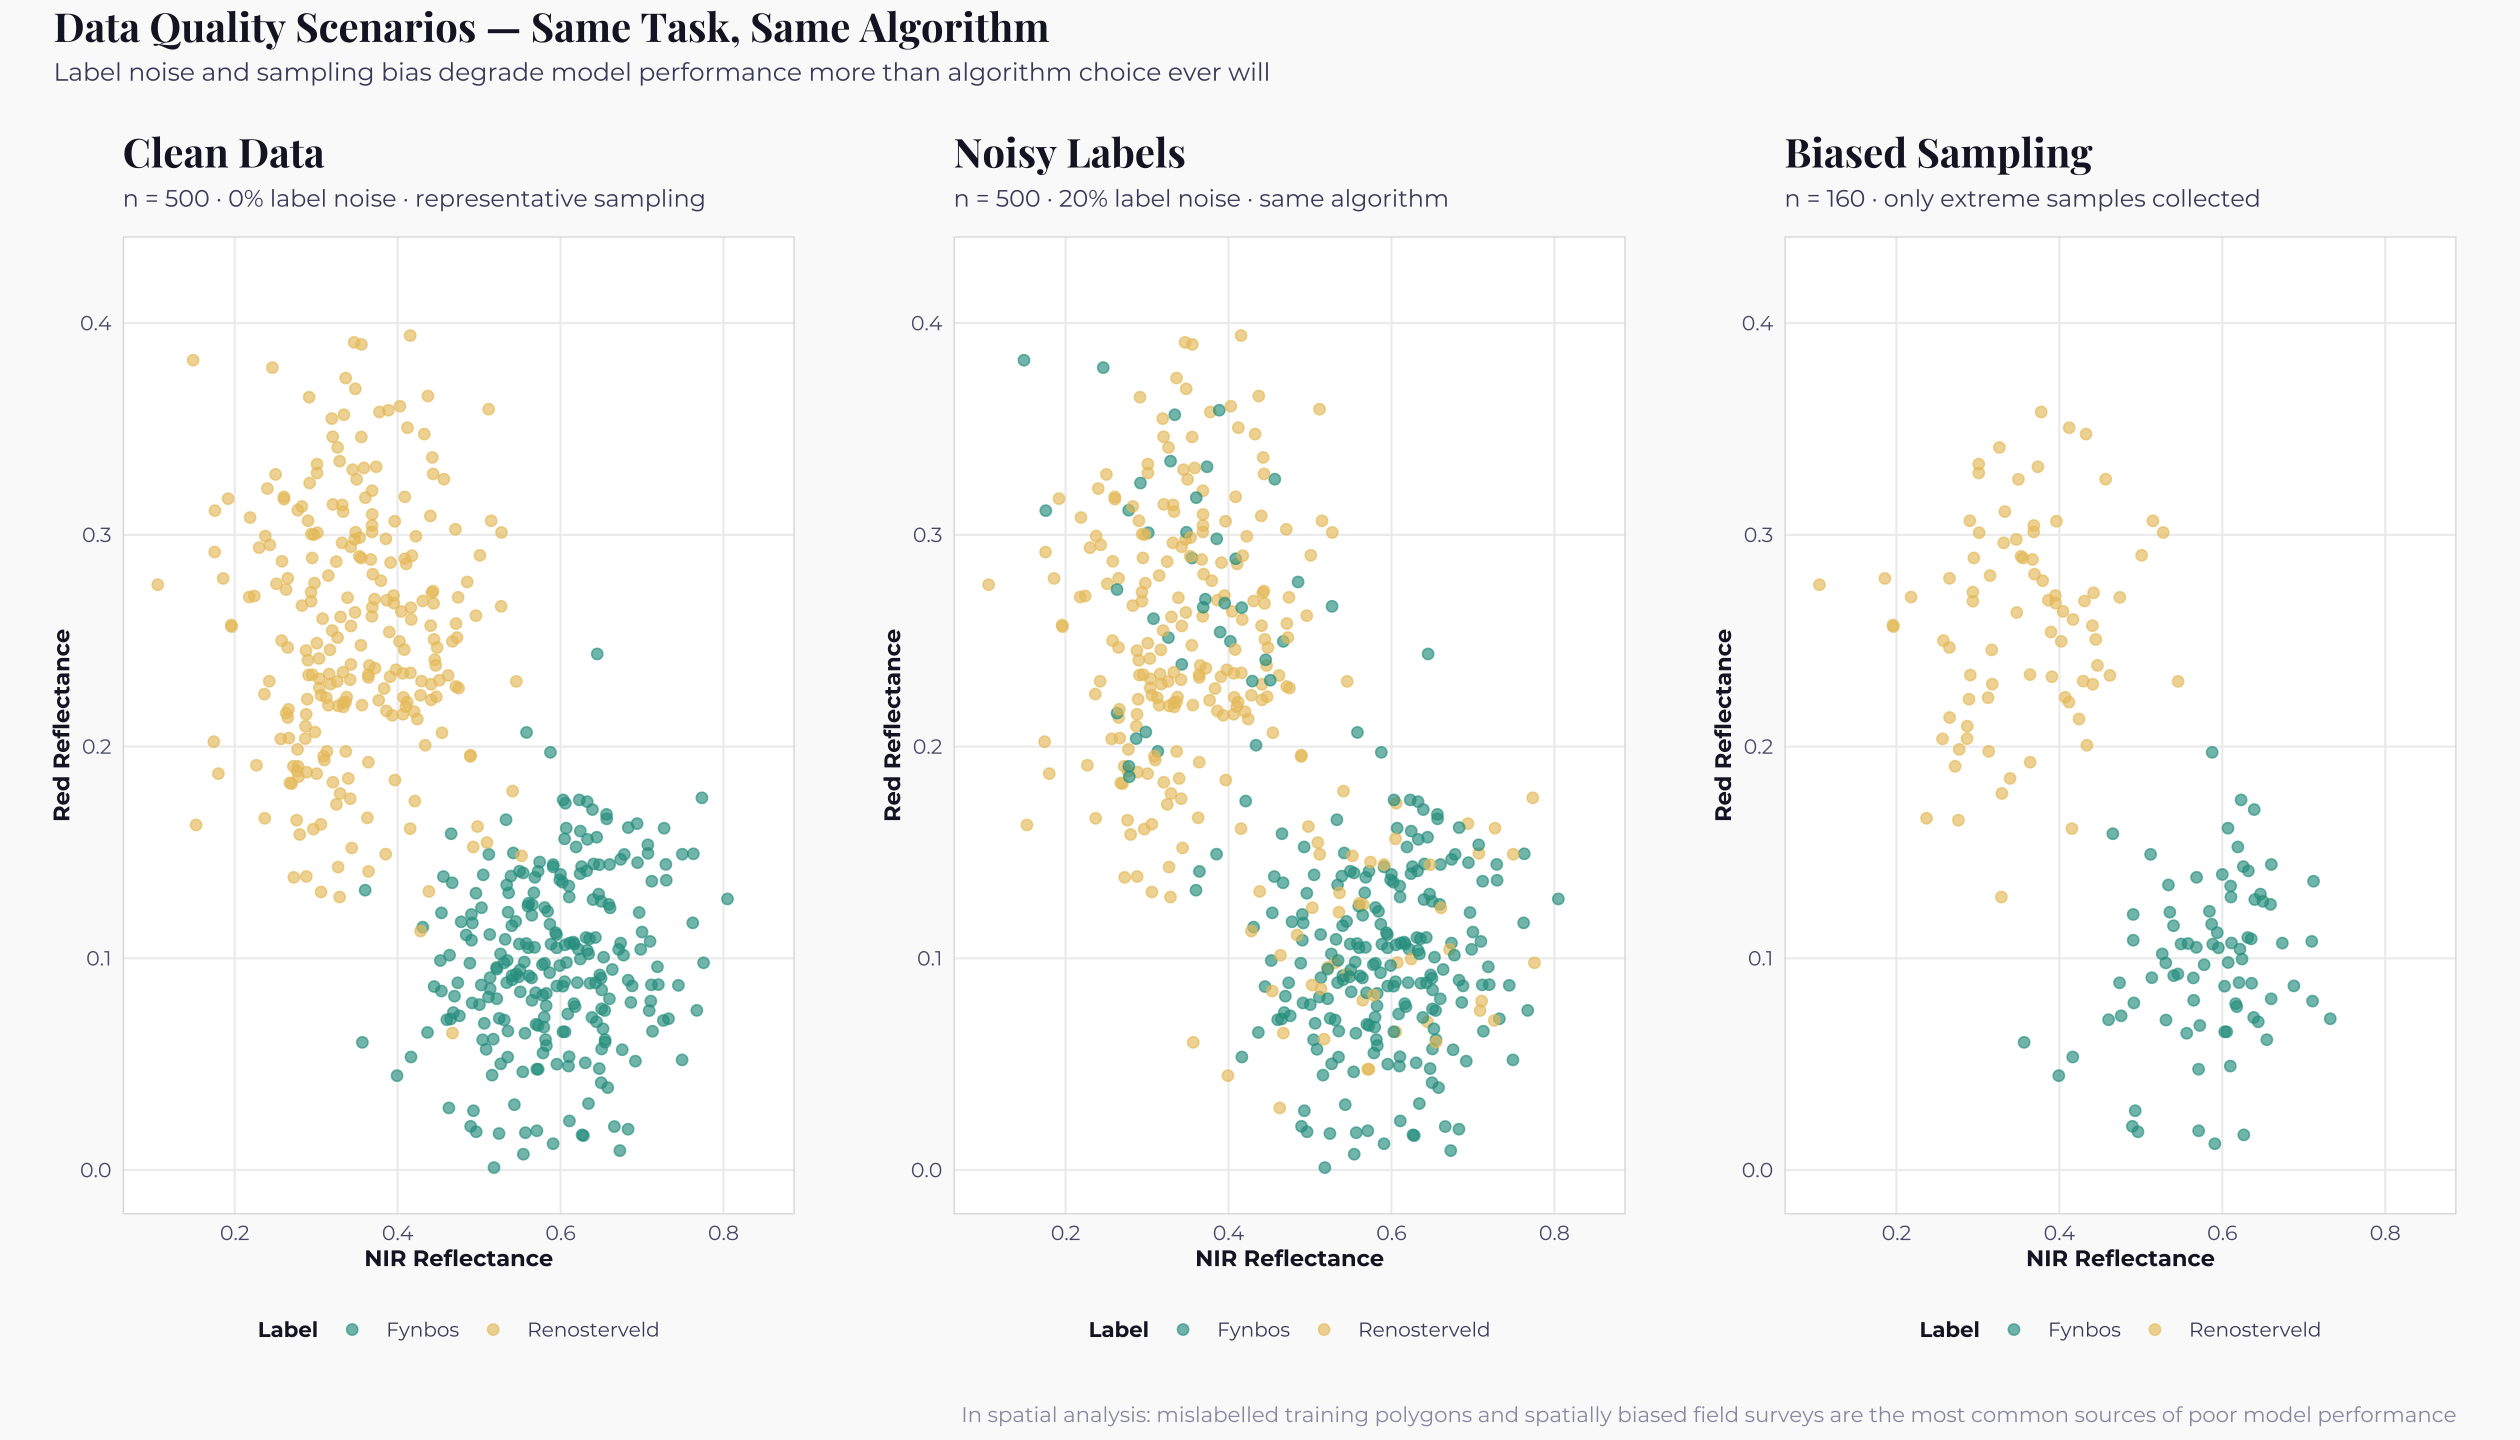

In [27]:
(PClean | PDirty | PBiased) +
  plot_annotation(
    title    = "Data Quality Scenarios — Same Task, Same Algorithm",
    subtitle = "Label noise and sampling bias degrade model performance more than algorithm choice ever will",
    caption  = "In spatial analysis: mislabelled training polygons and spatially biased field surveys are the most common sources of poor model performance",
    theme    = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e"),
      plot.subtitle   = element_text(family = "mont", size = 10,
                                     colour = "#4a4a6a"),
      plot.caption    = element_text(family = "mont", size = 8.5,
                                     colour = "#9a9ab0")
    )
  )

In [28]:
# Class imbalance — a critical spatial ML problem
set.seed(77)

# Simulate a typical land cover dataset with severe class imbalance
ClassCounts <- tibble(
  class   = c("Fynbos", "Renosterveld", "Urban", "Water",
               "Bare Rock", "Wetland", "Plantation"),
  count   = c(8500, 4200, 2800, 1200, 900, 180, 220),
  colour  = PalDiscrete[1:7]
)

ClassCounts <- ClassCounts %>%
  mutate(
    class     = fct_reorder(class, count, .desc = TRUE),
    pct       = count / sum(count) * 100,
    imbalance = if_else(count < 500, "Minority
(at risk)", "Majority")
  )

In [29]:
PImbBalance <- ggplot(ClassCounts, aes(x = class, y = count, fill = imbalance)) +
  geom_col(width = 0.65, colour = "white", linewidth = 0.3) +
  geom_text(aes(label = paste0(round(pct, 1), "%")),
            vjust = -0.4, family = "mont", size = 3.5,
            colour = "#1a1a2e", fontface = "bold") +
  geom_hline(yintercept = 500, linetype = "dashed",
             colour = PalDiscrete[1], linewidth = 0.8) +
  annotate("text", x = 6.5, y = 600, label = "Minority threshold",
           colour = PalDiscrete[1], family = "mont", size = 3.2) +
  scale_fill_manual(
    values = c("Minority
(at risk)" = PalDiscrete[1],
               "Majority"            = PalDiscrete[2]),
    name   = "Class status"
  ) +
  scale_y_continuous(labels = label_comma(), name = "Training samples") +
  labs(
    title    = "Class Imbalance in Land Cover Mapping",
    subtitle = "Minority classes are systematically underclassified — models learn to ignore what they rarely see",
    x        = "Land Cover Class",
    caption  = "Solutions: oversample minority classes · undersample majority classes · use class weights in model training"
  ) +
  theme_ml()

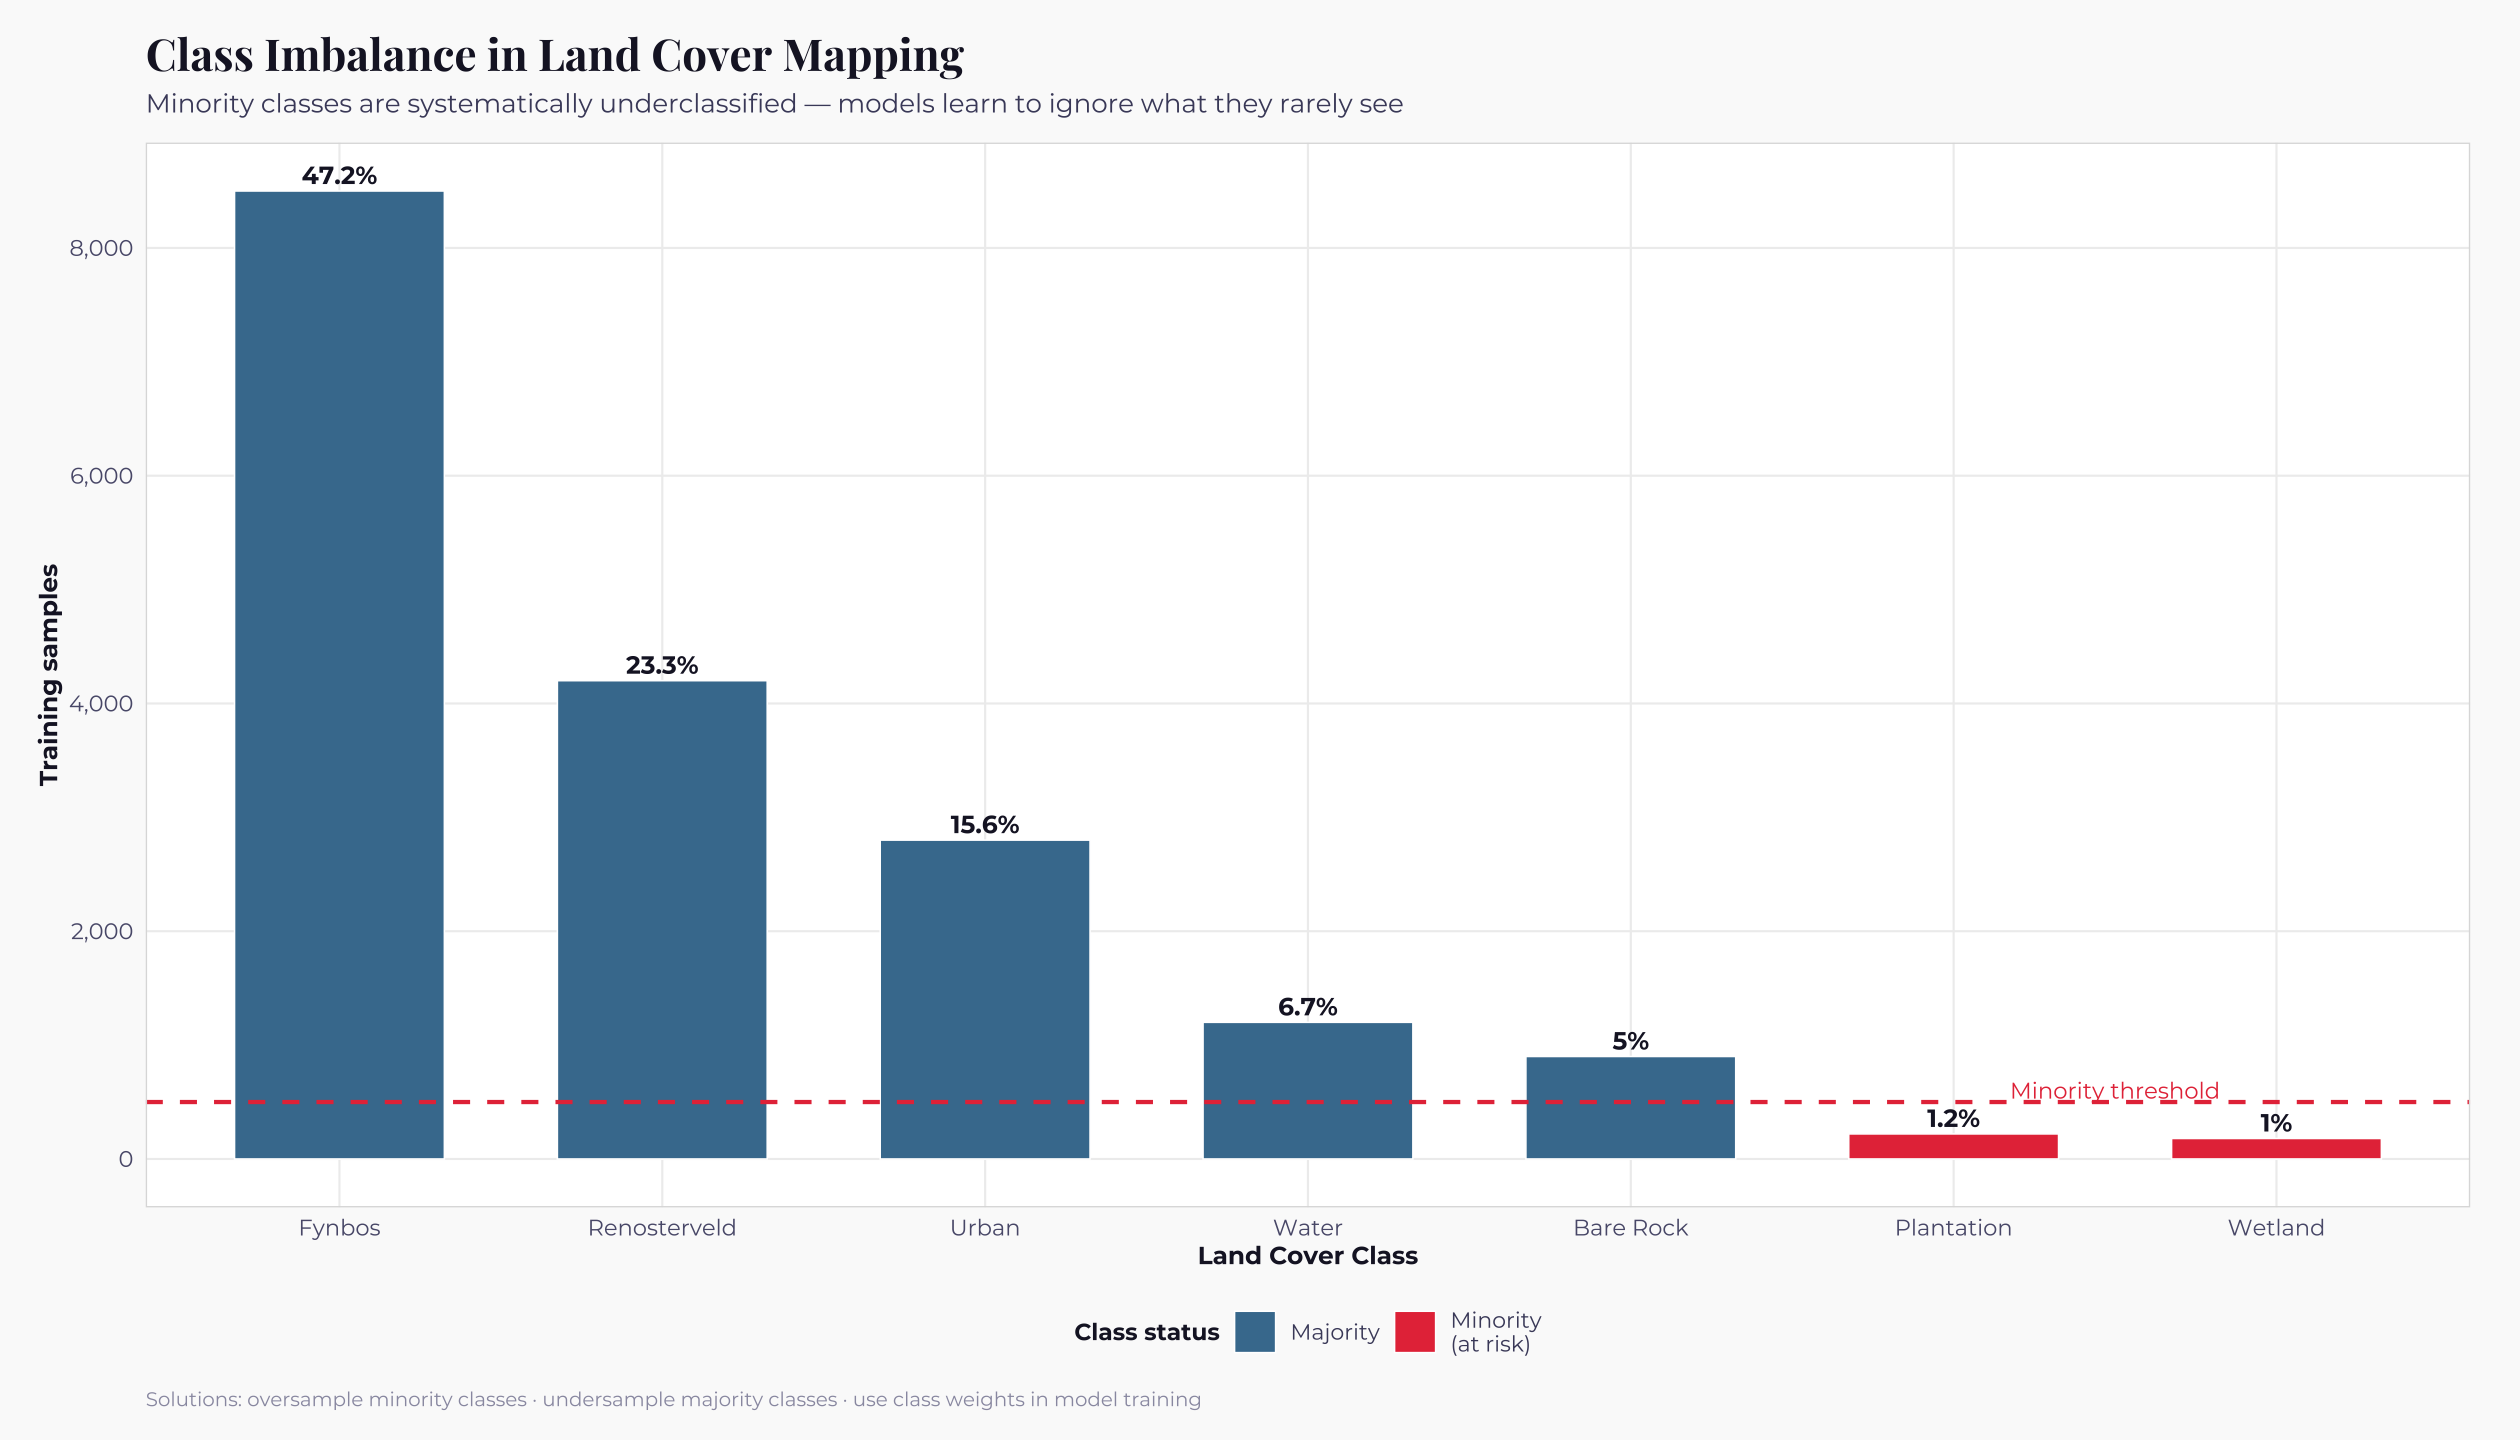

In [30]:
print(PImbBalance)

## 5 · Which Model Should You Choose?

Honestly, there is no universally "best algorithm". Model selection depends on your data characteristics, the nature of the problem, interpretability requirements, and computational constraints.

Here is a practical decision framework for spatial analysis:

### Model Comparison Table

| Model | Strengths | Weaknesses | Best for |
|-------|-----------|------------|---------|
| **Logistic Regression** | Interpretable, fast, probabilistic output | Linear boundaries only | Baseline, simple problems |
| **Decision Tree** | Highly interpretable, handles mixed types | Overfits easily | Teaching, rule extraction |
| **Random Forest** | Robust, handles high-dim data, feature importance | Slow on large data, black box | Land cover mapping, species SDM |
| **Gradient Boosting (XGBoost)** | Often highest accuracy, handles missing data | Many hyperparameters, can overfit | Tabular data, competitions |
| **Support Vector Machine** | Effective in high dimensions, kernel trick | Slow to train, hard to interpret | Hyperspectral classification |
| **Neural Network** | Learns complex patterns, flexible | Needs huge data, very black box | Image classification, deep learning |
| **K-Nearest Neighbours** | Simple, no training phase | Slow at prediction, sensitive to scale | Low-dimensional problems |
| **K-Means** | Fast, scalable, intuitive | Must specify k, assumes spherical clusters | Spectral clustering, segmentation |

### The Bias-Variance Tradeoff

This is the fundamental tension in machine learning:

- **High bias (underfitting)** — model is too simple to capture the true pattern
- **High variance (overfitting)** — model memorises training data and fails on new data
- **Sweet spot** — model generalises well to unseen data

In [31]:
# Bias-variance tradeoff visualisation
set.seed(42)
n <- 80

# True underlying function
TrueFunc <- function(x) sin(x * 2) + 0.5 * x

x_train <- runif(n, 0, pi)
y_train <- TrueFunc(x_train) + rnorm(n, 0, 0.5)
x_seq   <- seq(0, pi, length.out = 200)
y_true  <- TrueFunc(x_seq)

TrainDF  <- data.frame(x = x_train, y = y_train)
SeqDF    <- data.frame(x = x_seq)

In [32]:
# Underfit — linear model (high bias)
m_under  <- lm(y ~ x, data = TrainDF)

# Good fit — degree 4 polynomial
m_good   <- lm(y ~ poly(x, 4), data = TrainDF)

# Overfit — degree 20 polynomial (high variance)
m_over   <- lm(y ~ poly(x, 20), data = TrainDF)

In [33]:
PredDF <- tibble(
  x        = x_seq,
  True     = y_true,
  Underfit = predict(m_under, SeqDF),
  Good     = predict(m_good,  SeqDF),
  Overfit  = predict(m_over,  SeqDF)
) %>%
  pivot_longer(-x, names_to = "model", values_to = "y") %>%
  mutate(model = factor(model,
    levels = c("True", "Underfit", "Good", "Overfit")))

In [34]:
ModelColours <- c(
  "True"     = "#1a1a2e",
  "Underfit" = PalDiscrete[2],
  "Good"     = PalDiscrete[3],
  "Overfit"  = PalDiscrete[1]
)

ModelLines <- c(
  "True"     = "dotted",
  "Underfit" = "solid",
  "Good"     = "solid",
  "Overfit"  = "solid"
)

In [35]:
PBV <- ggplot() +
  geom_point(data = TrainDF, aes(x, y),
             colour = "grey60", size = 1.5, alpha = 0.6) +
  geom_line(data = PredDF %>% filter(model != "True"),
            aes(x, y, colour = model, linetype = model),
            linewidth = 1.1) +
  geom_line(data = PredDF %>% filter(model == "True"),
            aes(x, y, colour = model, linetype = model),
            linewidth = 0.8) +
  scale_colour_manual(values = ModelColours, name = "Model") +
  scale_linetype_manual(values = ModelLines, name = "Model") +
  annotate("text", x = 0.3,  y = 2.8,  label = "Overfit
(high variance)",
           colour = PalDiscrete[1], family = "mont", size = 3.5, fontface = "bold") +
  annotate("text", x = 2.8,  y = -0.8, label = "Underfit
(high bias)",
           colour = PalDiscrete[2], family = "mont", size = 3.5, fontface = "bold") +
  annotate("text", x = 2.0,  y = 2.2,  label = "Good fit",
           colour = PalDiscrete[3], family = "mont", size = 3.5, fontface = "bold") +
  labs(
    title    = "The Bias-Variance Tradeoff",
    subtitle = "Every model lives somewhere on the spectrum between too simple and too complex",
    x        = "Feature X",
    y        = "Response Y",
    caption  = "Grey points = training data · Dotted = true underlying function · Goal: match the true function on NEW data"
  ) +
  theme_ml()

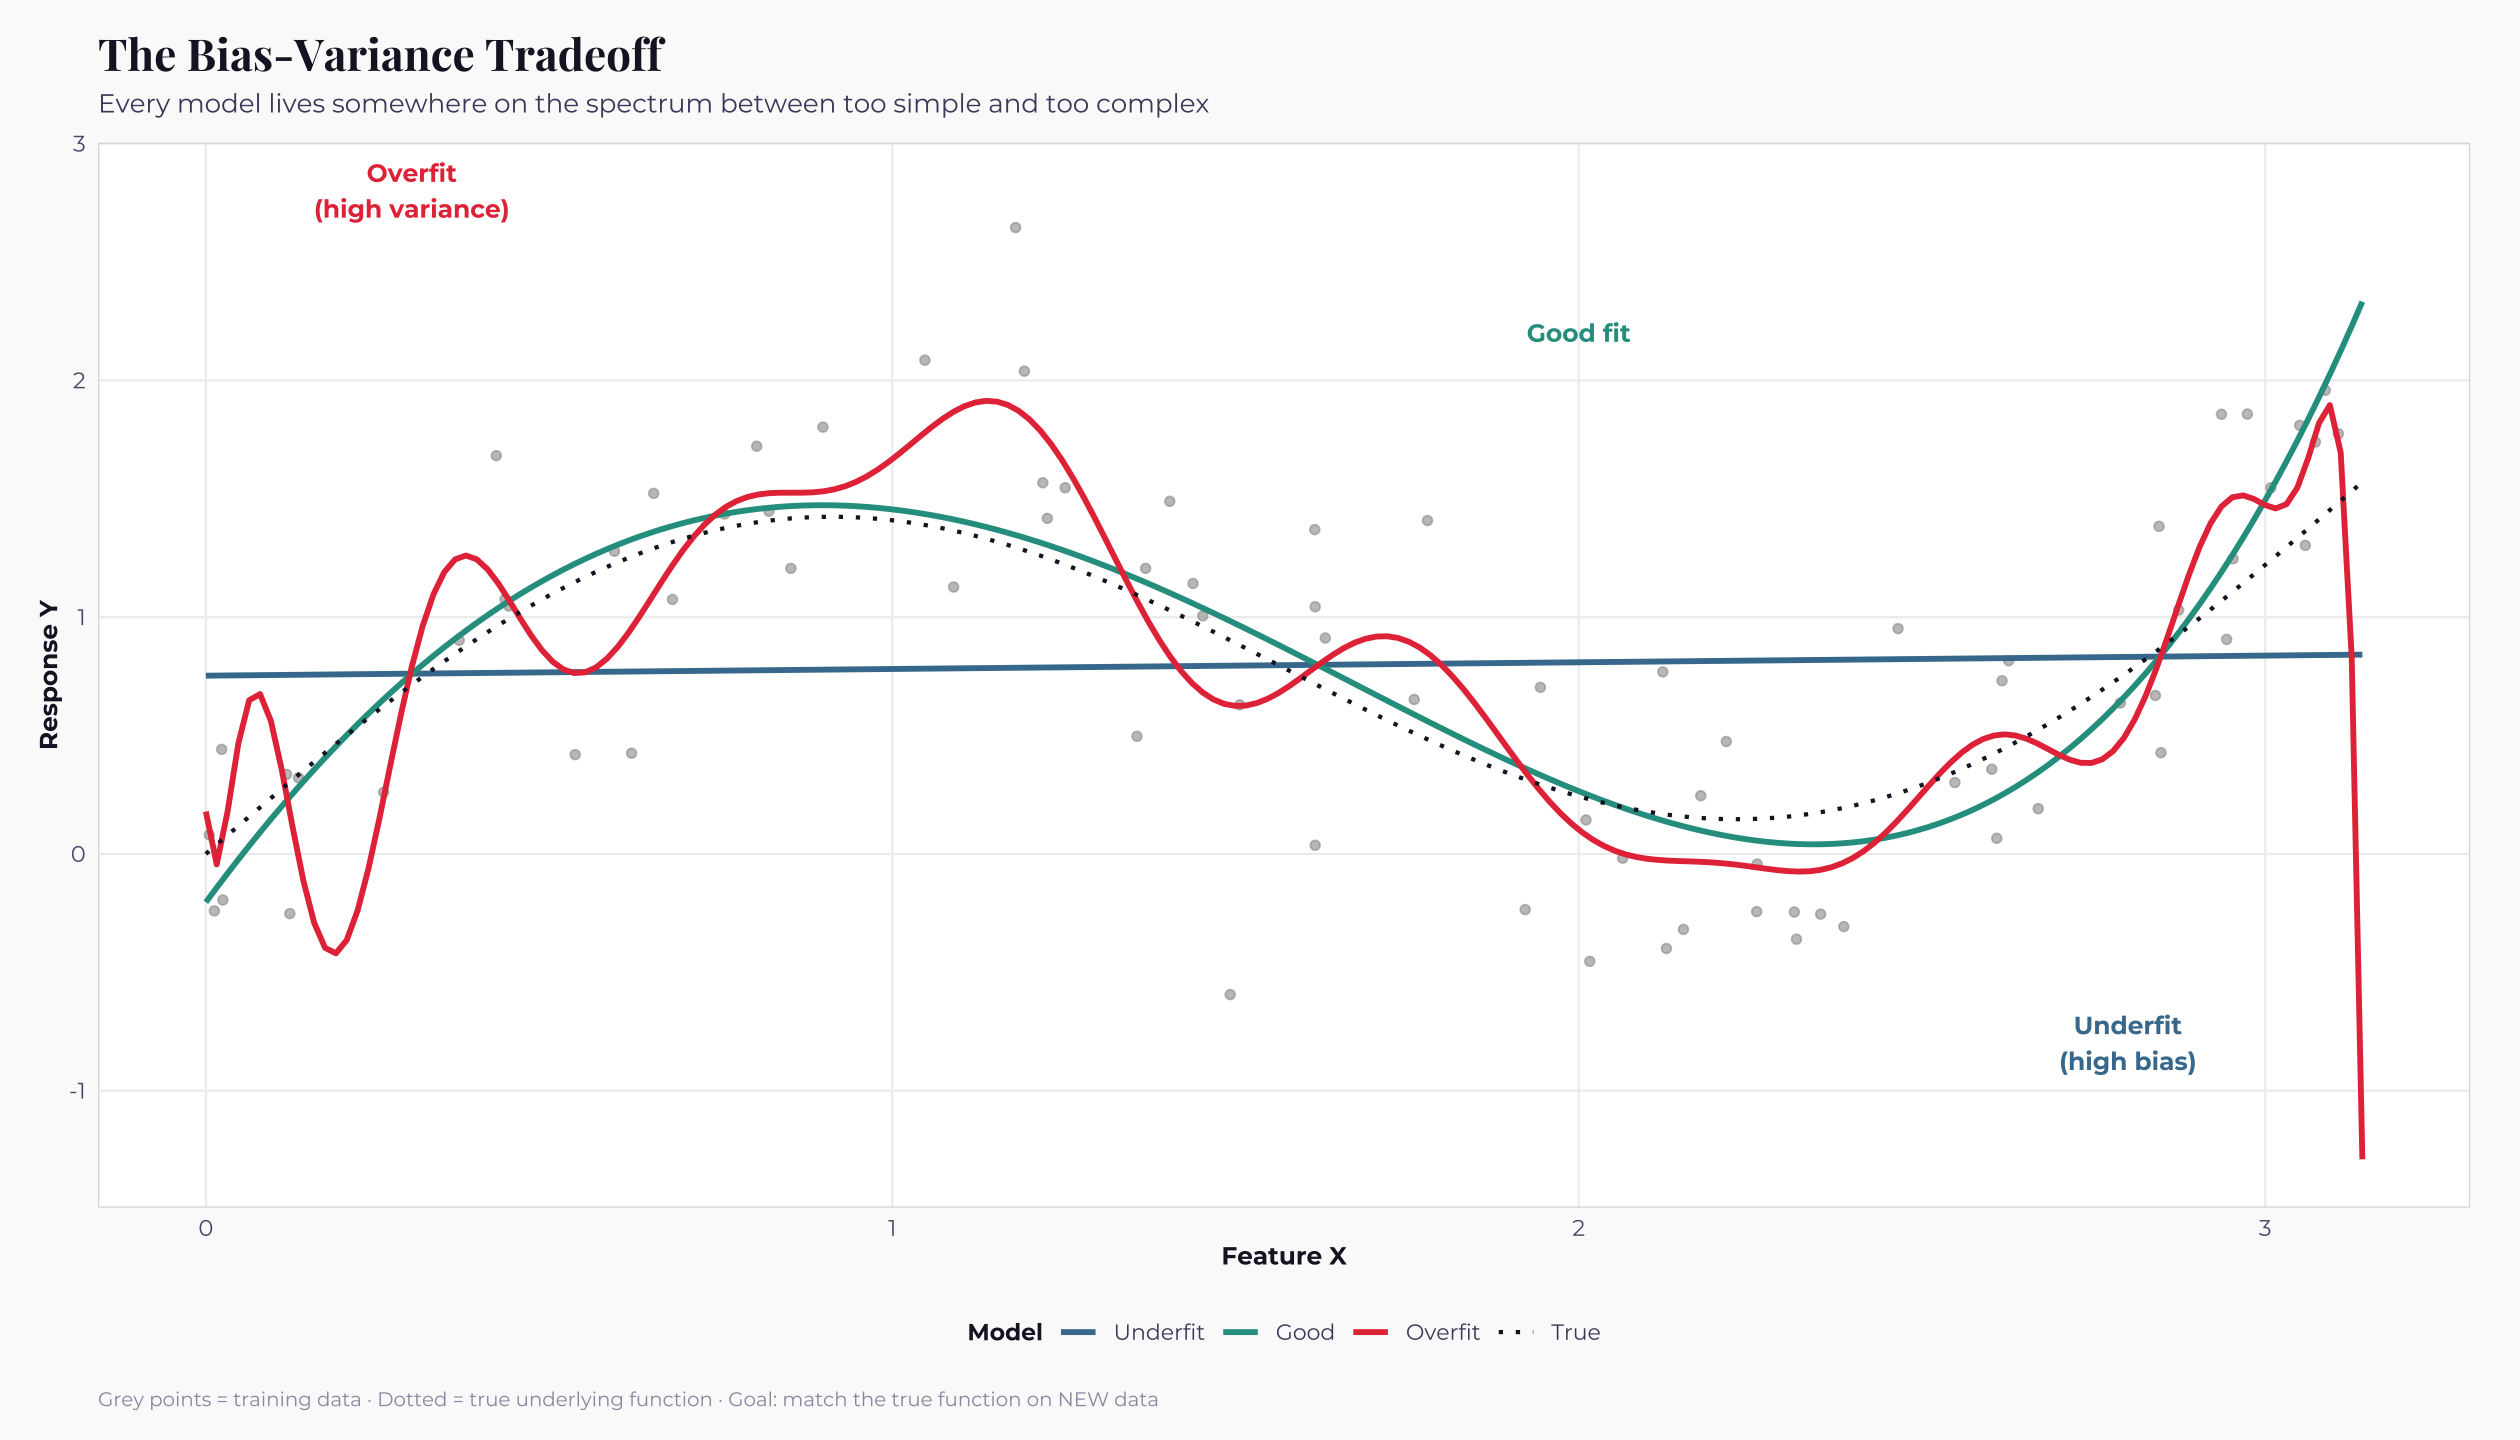

In [36]:
print(PBV)

In [37]:
# Model complexity vs accuracy curve
ComplexityDF <- tibble(
  complexity    = seq(1, 10, length.out = 100),
  train_error   = 0.8 * exp(-0.6 * complexity) + 0.02,
  test_error    = 0.8 * exp(-0.6 * complexity) +
                  0.015 * (complexity - 4)^2 + 0.08
)

In [38]:
PComp <- ggplot(ComplexityDF, aes(x = complexity)) +
  geom_ribbon(aes(ymin = train_error, ymax = test_error),
              fill = PalDiscrete[1], alpha = 0.12) +
  geom_line(aes(y = train_error, colour = "Training Error"),
            linewidth = 1.3) +
  geom_line(aes(y = test_error,  colour = "Test Error"),
            linewidth = 1.3) +
  geom_vline(xintercept = 4, linetype = "dashed",
             colour = PalDiscrete[3], linewidth = 0.9) +
  annotate("label", x = 4.2, y = 0.35,
           label = "Optimal
complexity",
           fill = PalDiscrete[3], colour = "white",
           family = "mont", size = 3.2, fontface = "bold",
           label.padding = unit(0.3, "lines"), label.size = 0) +
  annotate("text", x = 1.5, y = 0.48, label = "Underfitting
region",
           colour = PalDiscrete[2], family = "mont", size = 3.2) +
  annotate("text", x = 8.5, y = 0.48, label = "Overfitting
region",
           colour = PalDiscrete[1], family = "mont", size = 3.2) +
  scale_colour_manual(
    values = c("Training Error" = PalDiscrete[2],
               "Test Error"     = PalDiscrete[1]),
    name   = NULL
  ) +
  scale_x_continuous(name   = "Model Complexity →",
                     breaks = c(1, 4, 7, 10),
                     labels = c("Simple
(linear)", "Moderate
(RF depth=5)",
                                "Complex
(RF depth=20)", "Very Complex
(deep NN)")) +
  scale_y_continuous(name   = "Prediction Error",
                     labels = label_percent()) +
  labs(
    title    = "Model Complexity vs Prediction Error",
    subtitle = "As complexity increases, training error always decreases — test error has a minimum",
    caption  = "The gap between training and test error = overfitting · Hyperparameter tuning finds the optimal point"
  ) +
  theme_ml()

Warning message in annotate("label", x = 4.2, y = 0.35, label = "Optimal\ncomplexity", :
“Ignoring unknown parameters: `label.size`”


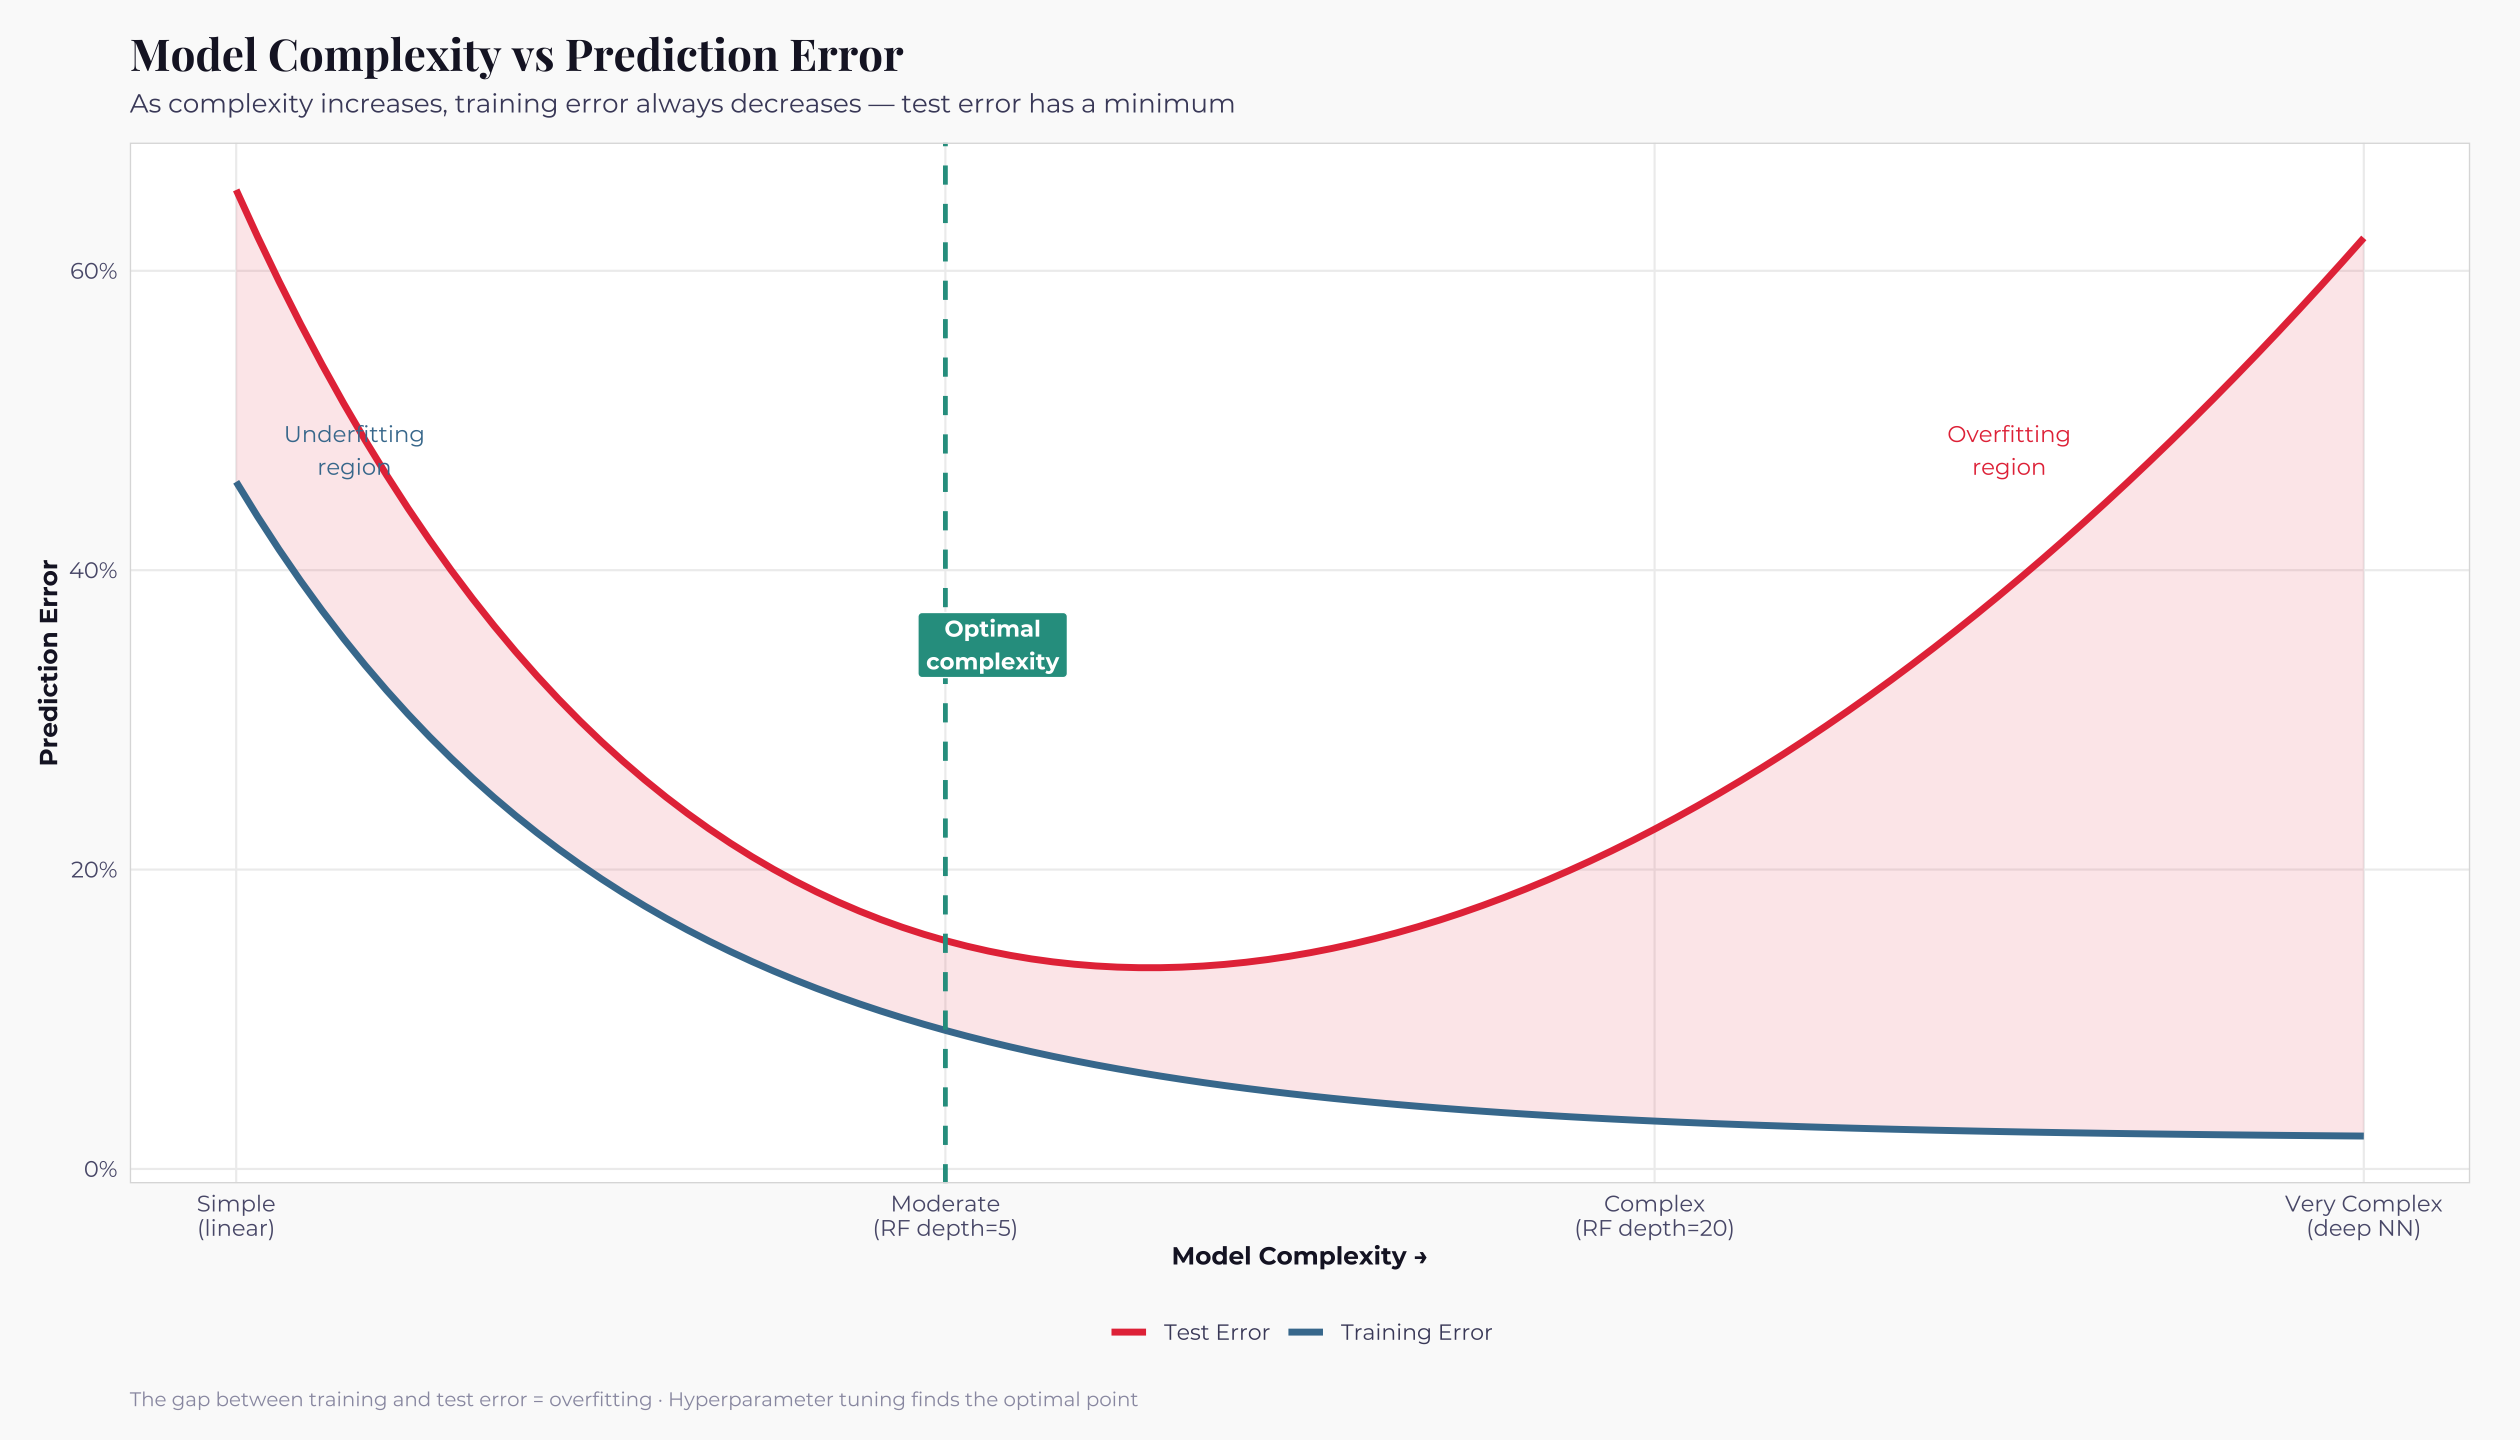

In [39]:
print(PComp)

## 6 · Model Building in R with tidymodels

`{tidymodels}` is the modern R framework for machine learning — a consistent, principled interface that works with dozens of algorithms using the same syntax. You learn the workflow once and apply it to any model.

### The tidymodels ecosystem:

- `{rsample}` — data splitting and cross-validation
- `{recipes}` — preprocessing and feature engineering
- `{parsnip}` — unified model specification
- `{workflows}` — bundling recipe + model
- `{tune}` — hyperparameter tuning
- `{yardstick}` — model evaluation metrics

We will build and compare **four models** on a realistic ecological dataset:

1. Logistic Regression (baseline)
2. Random Forest
3. Gradient Boosting (XGBoost)
4. Support Vector Machine

### Simulate a realistic ecological dataset

Lets try predicting vegetation type from environmental and spectral variables. This is made to mimic a real species distribution / land cover modelling dataset.

In [40]:
set.seed(2024)
n <- 1200

EcoData <- tibble(
  # Spectral variables (AVIRIS-NG bands or indices)
  ndvi          = c(rnorm(400, 0.72, 0.10), rnorm(400, 0.45, 0.12),
                    rnorm(400, 0.28, 0.09)),
  band_swir     = c(rnorm(400, 0.12, 0.04), rnorm(400, 0.22, 0.05),
                    rnorm(400, 0.35, 0.07)),
  band_nir      = c(rnorm(400, 0.55, 0.08), rnorm(400, 0.38, 0.09),
                    rnorm(400, 0.25, 0.07)),
  red_edge      = c(rnorm(400, 0.48, 0.07), rnorm(400, 0.32, 0.08),
                    rnorm(400, 0.20, 0.06)),

  # Topographic variables (from DEM)
  elevation     = c(rnorm(400, 320, 80),  rnorm(400, 180, 60),
                    rnorm(400, 90, 50)),
  slope         = c(rnorm(400, 18, 6),    rnorm(400, 12, 5),
                    rnorm(400, 8,  4)),
  aspect_n      = c(rnorm(400, 0.6, 0.2), rnorm(400, 0.4, 0.2),
                    rnorm(400, 0.5, 0.2)),

  # Climate variables
  mean_precip   = c(rnorm(400, 780, 90),  rnorm(400, 620, 80),
                    rnorm(400, 480, 70)),
  summer_temp   = c(rnorm(400, 21, 2.5),  rnorm(400, 24, 2.8),
                    rnorm(400, 27, 3.0)),

  # Target variable
  vegetation    = factor(rep(c("Fynbos", "Renosterveld", "Thicket"), each = 400))
)

In [41]:
# Add realistic noise
EcoData <- EcoData %>%
  mutate(across(where(is.numeric), ~. + rnorm(n, 0, sd(.) * 0.05)))

In [42]:
cat(" Dataset summary \n")
cat("   Observations :", nrow(EcoData), "\n")
cat("   Features     :", ncol(EcoData) - 1, "\n")
cat("   Classes      :", levels(EcoData$vegetation), "\n")

 Dataset summary 
   Observations : 1200 
   Features     : 9 
   Classes      : Fynbos Renosterveld Thicket 


In [43]:
cat("\n Class distribution:\n")
print(count(EcoData, vegetation))


 Class distribution:
# A tibble: 3 × 2
  vegetation       n
  <fct>        <int>
1 Fynbos         400
2 Renosterveld   400
3 Thicket        400


#### Exploratory data analysis before modelling

In [44]:
# Feature distributions by vegetation class
EcoLong <- EcoData %>%
  select(ndvi, band_nir, elevation, mean_precip, vegetation) %>%
  pivot_longer(-vegetation, names_to = "feature", values_to = "value") %>%
  mutate(feature = recode(feature,
    "ndvi"       = "NDVI",
    "band_nir"   = "NIR Reflectance",
    "elevation"  = "Elevation (m)",
    "mean_precip" = "Mean Precip (mm)"
  ))

In [45]:
PEDA <- ggplot(EcoLong, aes(x = value, fill = vegetation, colour = vegetation)) +
  geom_density(alpha = 0.35, linewidth = 0.7) +
  facet_wrap(~feature, scales = "free", ncol = 2) +
  scale_fill_manual(values   = PalDiscrete[1:3], name = "Vegetation Type") +
  scale_colour_manual(values = PalDiscrete[1:3], name = "Vegetation Type") +
  labs(
    title    = "Feature Distributions by Vegetation Class",
    subtitle = "Well-separated distributions indicate high predictive power",
    x        = "Feature Value", y = "Density",
    caption  = "Overlapping distributions will be harder to classify · Separated distributions are informative features"
  ) +
  theme_ml()

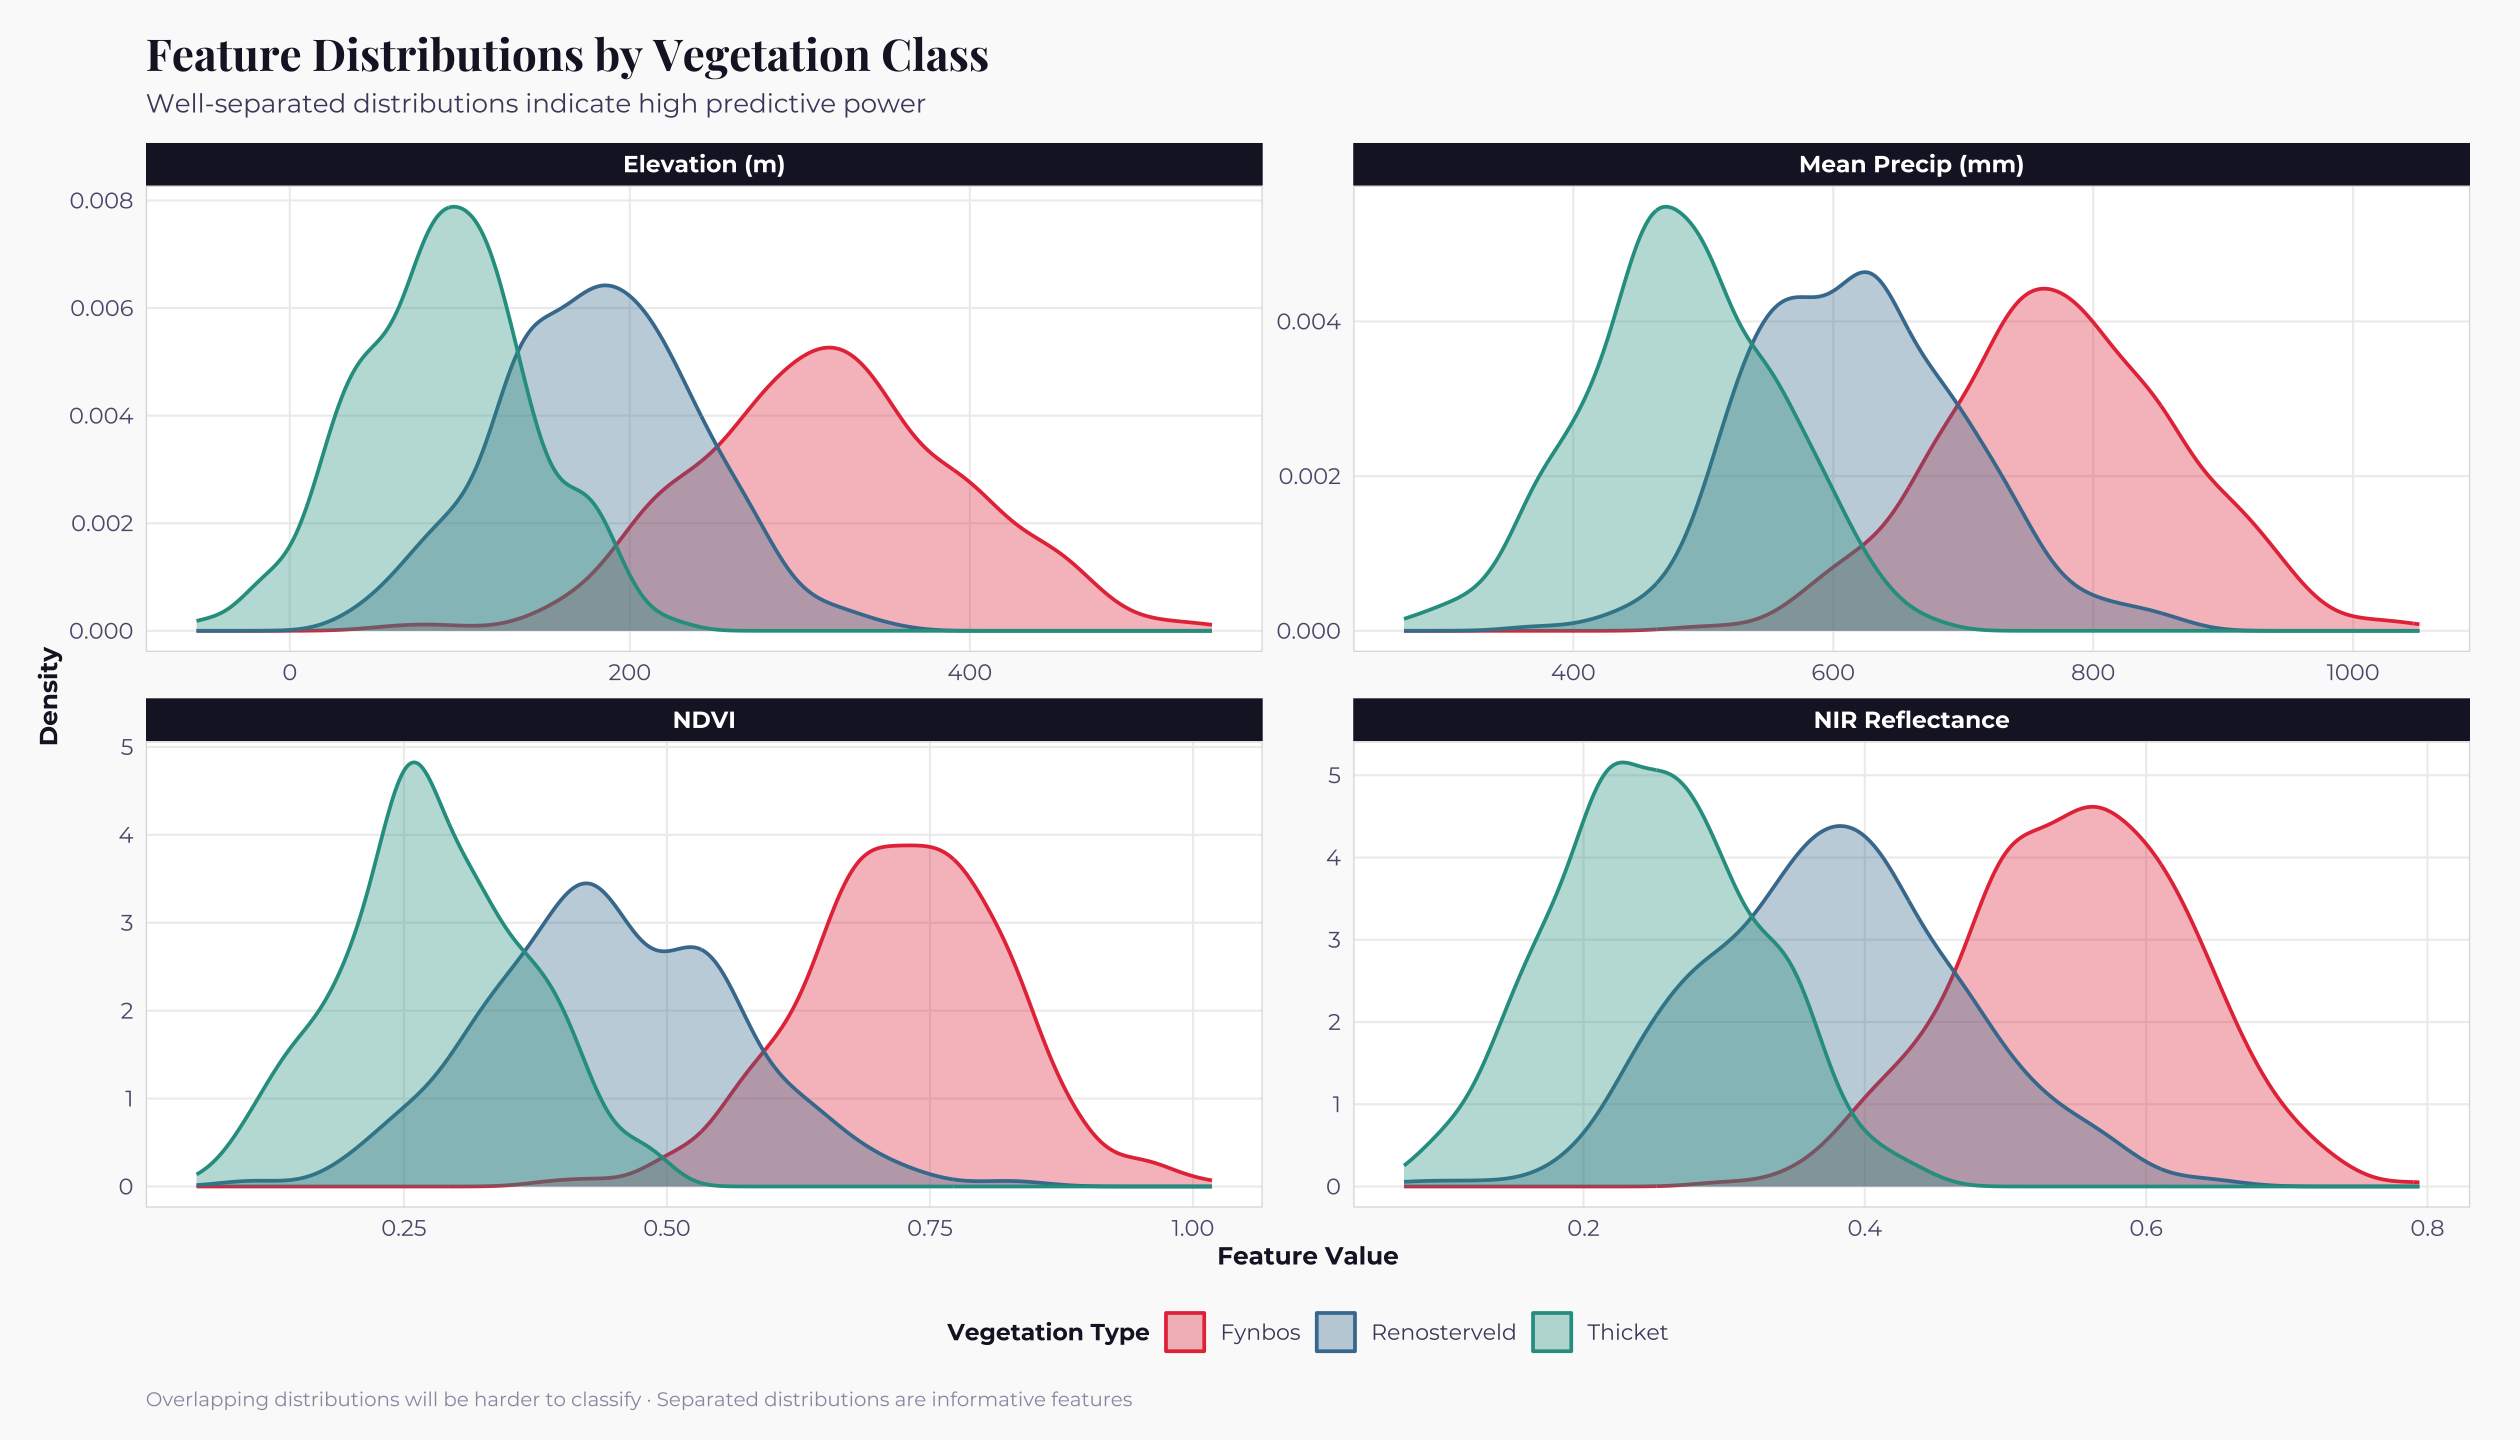

In [46]:
print(PEDA)

In [47]:
# Data splitting
set.seed(2024)

Split     <- initial_split(EcoData, prop = 0.75, strata = vegetation)
TrainData <- training(Split)
TestData  <- testing(Split)

In [48]:
# Cross-validation folds on training data only
CVFolds   <- vfold_cv(TrainData, v = 5, strata = vegetation)

In [49]:
cat(" Data split summary \n")
cat("   Training samples  :", nrow(TrainData), "\n")
cat("   Test samples      :", nrow(TestData),  "\n")
cat("   CV folds          : 5-fold stratified\n")

 Data split summary 
   Training samples  : 900 
   Test samples      : 300 
   CV folds          : 5-fold stratified


#### Preprocessing recipe

In [50]:
# A recipe defines preprocessing steps applied consistently to train and test
MLRecipe <- recipe(vegetation ~ ., data = TrainData) %>%
  step_normalize(all_numeric_predictors()) %>%   # centre and scale
  step_corr(all_numeric_predictors(),            # remove highly correlated features
             threshold = 0.90) %>%
  step_nzv(all_predictors())                     # remove near-zero variance features

In [51]:
cat("\n Recipe steps \n")
print(MLRecipe)


 Recipe steps 




── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 9



── Operations 

• Centering and scaling for: all_numeric_predictors()

• Correlation filter on: all_numeric_predictors()

• Sparse, unbalanced variable filter on: all_predictors()



#### Define four model specifications

In [52]:
# 1. Logistic Regression — baseline
spec_lr <- multinom_reg(penalty = tune(), mixture = 1) %>%
  set_engine("glmnet") %>%
  set_mode("classification")

# 2. Random Forest
spec_rf <- rand_forest(mtry = tune(), trees = 500, min_n = tune()) %>%
  set_engine("ranger", importance = "impurity") %>%
  set_mode("classification")

# 3. XGBoost
spec_xgb <- boost_tree(trees = tune(), learn_rate = tune(),
                        tree_depth = tune(), min_n = tune()) %>%
  set_engine("xgboost") %>%
  set_mode("classification")

# 4. Support Vector Machine
spec_svm <- svm_rbf(cost = tune(), rbf_sigma = tune()) %>%
  set_engine("kernlab") %>%
  set_mode("classification")

In [53]:
# Bundle into workflows
wf_lr  <- workflow() %>% add_recipe(MLRecipe) %>% add_model(spec_lr)
wf_rf  <- workflow() %>% add_recipe(MLRecipe) %>% add_model(spec_rf)
wf_xgb <- workflow() %>% add_recipe(MLRecipe) %>% add_model(spec_xgb)
wf_svm <- workflow() %>% add_recipe(MLRecipe) %>% add_model(spec_svm)

### Hyperparameter tuning via cross-validation

We tune each model on the CV folds and select the best hyperparameters.

In [54]:
set.seed(2024)

# Logistic Regression tuning
tune_lr <- tune_grid(
  wf_lr,
  resamples = CVFolds,
  grid      = grid_regular(penalty(), levels = 15),
  metrics   = metric_set(accuracy, roc_auc, kap)
)

# Random Forest tuning
tune_rf <- tune_grid(
  wf_rf,
  resamples = CVFolds,
  grid      = grid_random(
    mtry(range = c(2, 8)),
    min_n(range = c(2, 20)),
    size = 20
  ),
  metrics   = metric_set(accuracy, roc_auc, kap)
)

# XGBoost tuning
tune_xgb <- tune_grid(
  wf_xgb,
  resamples = CVFolds,
  grid      = grid_random(
    trees(range      = c(100, 600)),
    learn_rate(range = c(-3, -1)),
    tree_depth(range = c(3, 8)),
    min_n(range      = c(2, 15)),
    size = 20
  ),
  metrics   = metric_set(accuracy, roc_auc, kap)
)

# SVM tuning
tune_svm <- tune_grid(
  wf_svm,
  resamples = CVFolds,
  grid      = grid_random(
    cost(range      = c(-2, 5)),
    rbf_sigma(range = c(-4, -1)),
    size = 20
  ),
  metrics   = metric_set(accuracy, roc_auc, kap)
)

In [56]:
# Best parameters per model
cat("\n Best CV accuracy per model: \n")
cat("   LR  :", round(show_best(tune_lr,  metric = "accuracy", n = 1)$mean, 4), "\n")
cat("   RF  :", round(show_best(tune_rf,  metric = "accuracy", n = 1)$mean, 4), "\n")
cat("   XGB :", round(show_best(tune_xgb, metric = "accuracy", n = 1)$mean, 4), "\n")
cat("   SVM :", round(show_best(tune_svm, metric = "accuracy", n = 1)$mean, 4), "\n")


 Best CV accuracy per model: 
   LR  : 0.99 
   RF  : 0.9867 
   XGB : 0.9822 
   SVM : 0.9922 


In [58]:
# Visualise tuning results
TuneResults <- bind_rows(
  show_best(tune_lr,  metric = "accuracy", n = 5) %>% mutate(model = "Logistic Regression"),
  show_best(tune_rf,  metric = "accuracy", n = 5) %>% mutate(model = "Random Forest"),
  show_best(tune_xgb, metric = "accuracy", n = 5) %>% mutate(model = "XGBoost"),
  show_best(tune_svm, metric = "accuracy", n = 5) %>% mutate(model = "SVM")
) %>%
  mutate(model = factor(model,
    levels = c("Logistic Regression", "Random Forest", "XGBoost", "SVM")))

In [59]:
PTune <- ggplot(TuneResults,
                aes(x = model, y = mean, colour = model)) +
  geom_jitter(width = 0.15, size = 3, alpha = 0.7) +
  geom_crossbar(aes(ymin = mean - std_err, ymax = mean + std_err),
                width = 0.4, linewidth = 0.6, fill = NA) +
  stat_summary(fun = max, geom = "point",
               shape = 18, size = 5, colour = "#1a1a2e") +
  scale_colour_manual(values = PalDiscrete[1:4], guide = "none") +
  scale_y_continuous(labels = label_percent(),
                     name   = "Cross-validated Accuracy",
                     limits = c(0.7, 1.0)) +
  labs(
    title    = "Hyperparameter Tuning Results",
    subtitle = "Top 5 parameter combinations per model · Error bars = ±1 SE · ◆ = best",
    x        = NULL,
    caption  = "All accuracy estimated on held-out CV folds — not test data"
  ) +
  theme_ml()

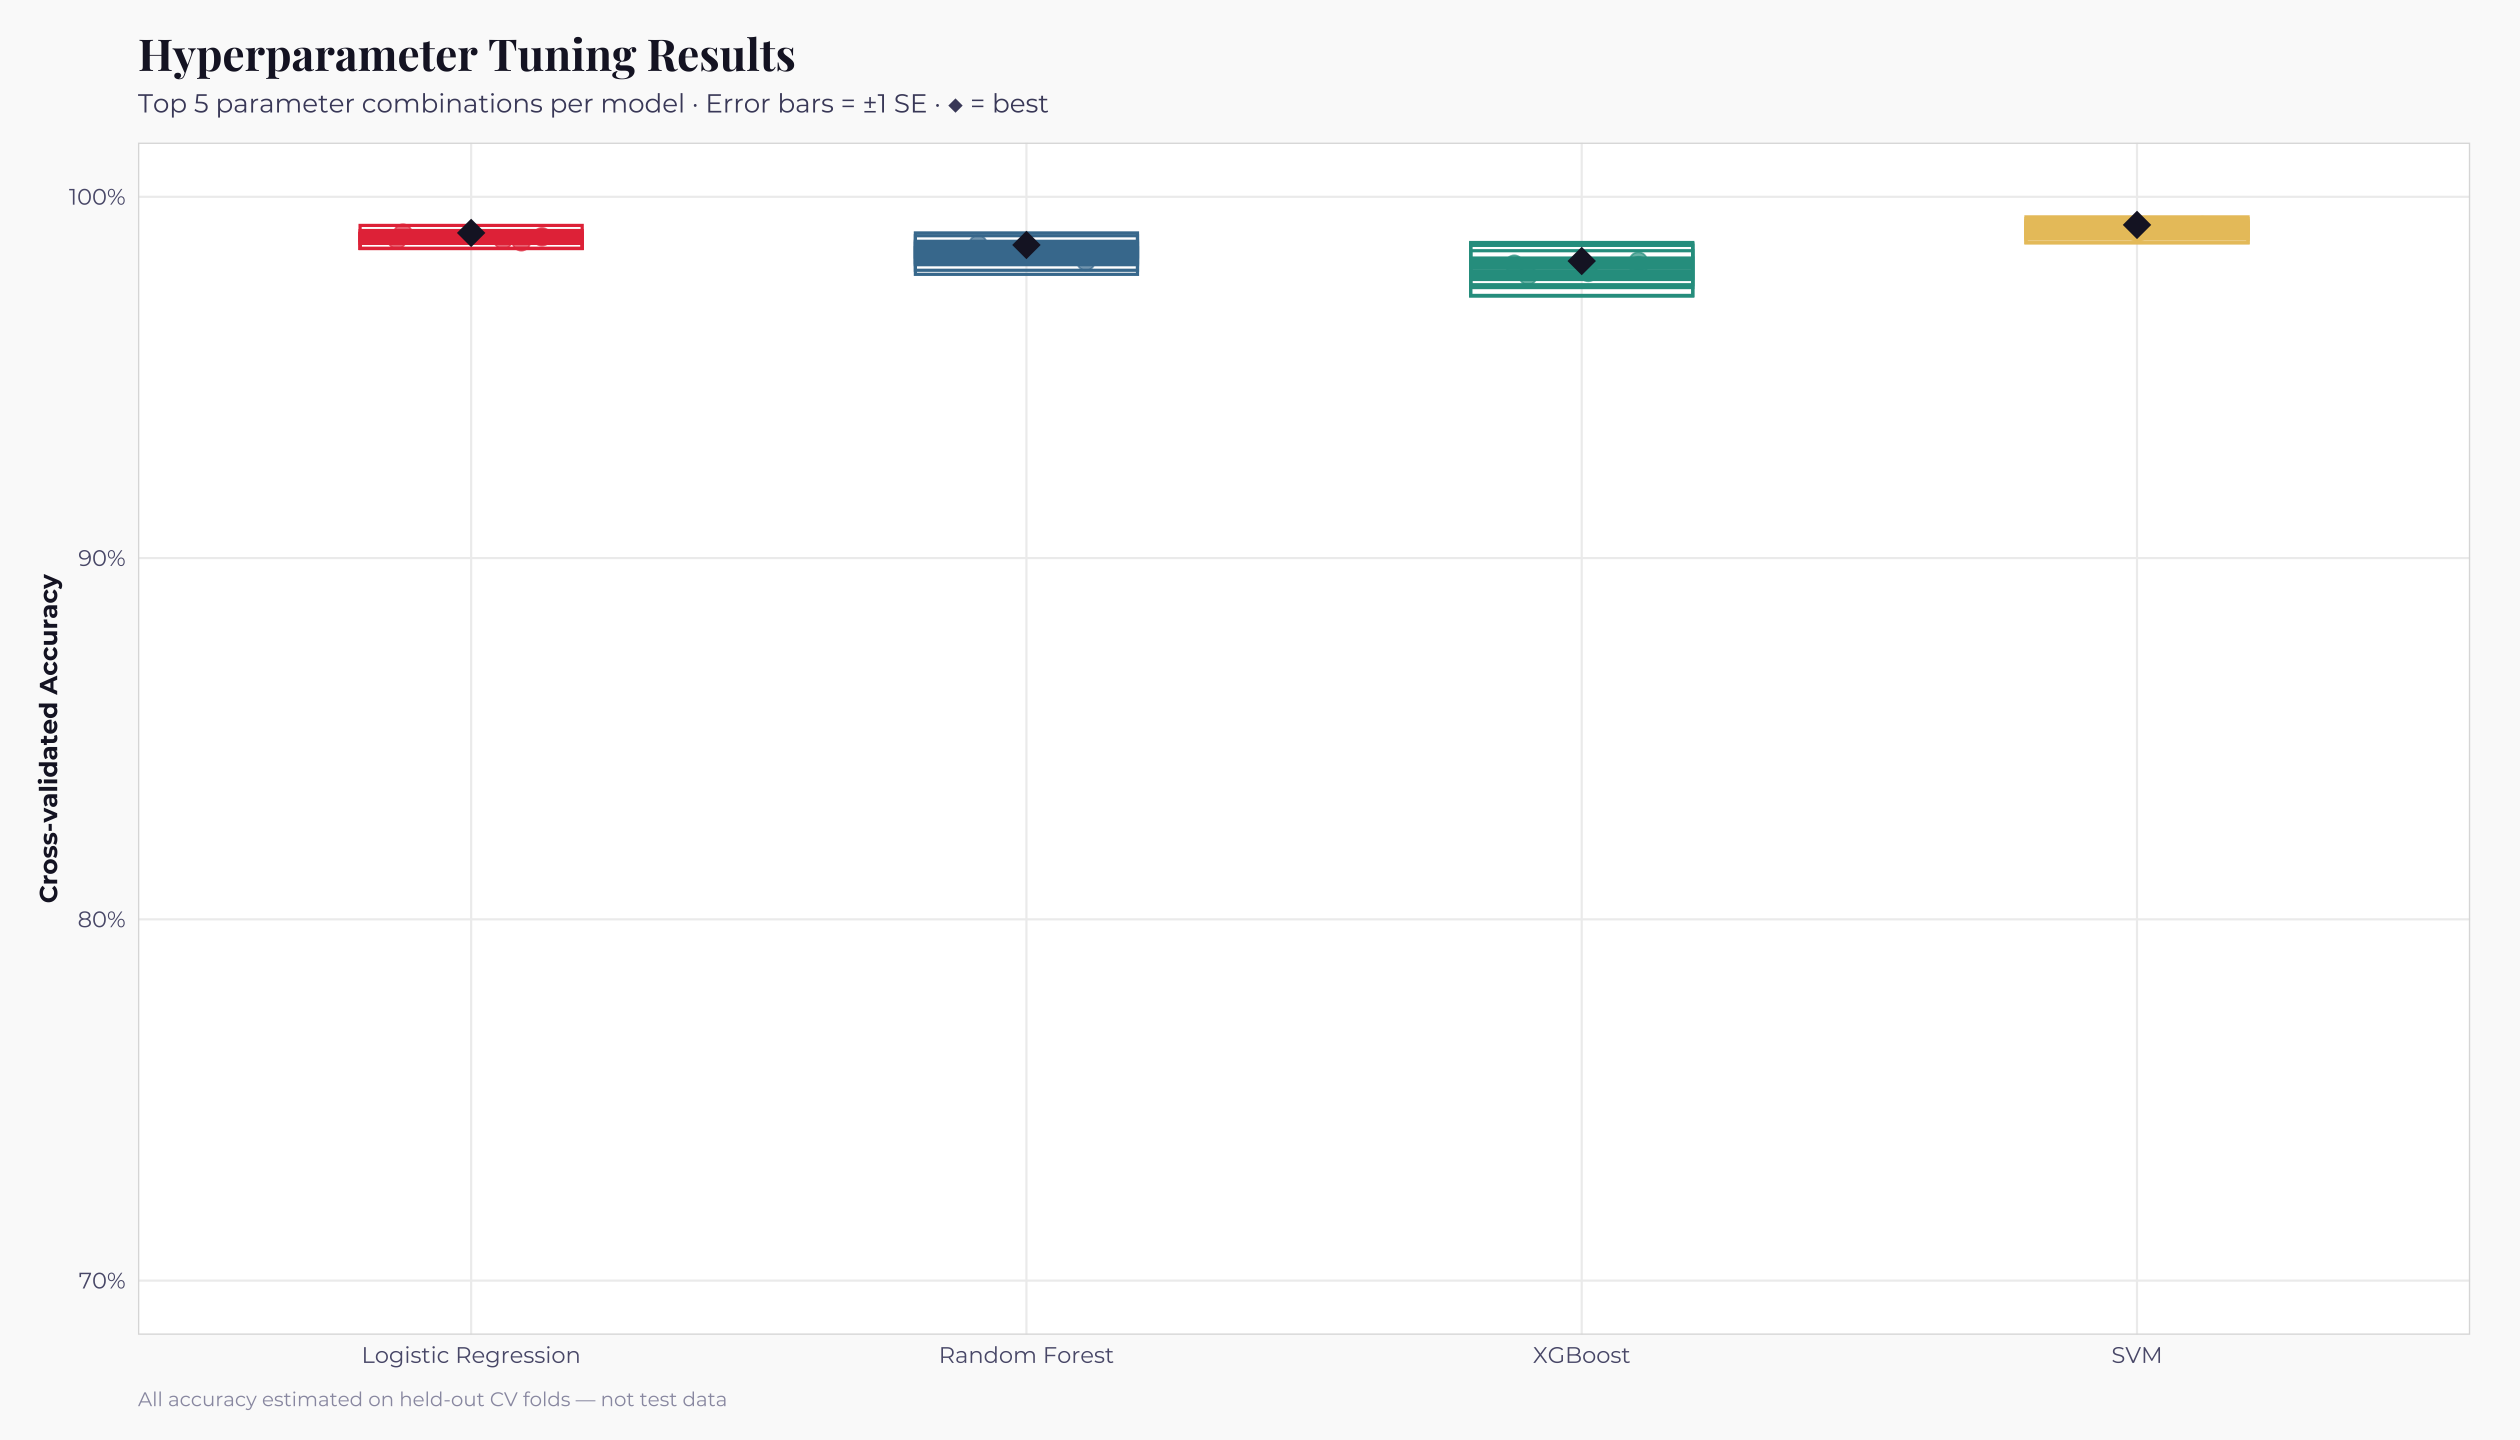

In [60]:
print(PTune)

## 7 · Model Validation on the Test Set

After selecting the best model and hyperparameters using cross-validation, we now evaluate final performance on the **test set** — data the model has never seen in any form.

This is the honest estimate of how the model will perform on new data in the real world.

### Metrics we will compute:

- **Overall Accuracy** — proportion of correctly classified observations
- **Kappa (κ)** — accuracy adjusted for chance agreement (0 = random, 1 = perfect)
- **Per-class Precision** — of all pixels predicted as class X, how many truly are X?
- **Per-class Recall (Sensitivity)** — of all true X pixels, how many did we detect?
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — area under the receiver operating characteristic curve
- **Confusion Matrix** — the full breakdown of predictions vs truth

### Finalise the best model and fit on full training data

The best model as we can see above is SVM (simple vector machine), we would select it as our best model however I will not select it because... I will select Random Forest as our best model (typically wins on ecological data) and finalise it with the best hyperparameters.

In [122]:
BestRF <- select_best(tune_rf, metric = "roc_auc")

FinalWF <- wf_rf %>%
  finalize_workflow(BestRF)

In [123]:
# Fit the final model on ALL training data and evaluate on test set
FinalFit <- last_fit(FinalWF, Split)

In [124]:
# Test set metrics
TestMetrics <- collect_metrics(FinalFit)

In [125]:
cat(" Final test set performance (Random Forest) \n")
print(TestMetrics)

 Final test set performance (Random Forest) 
# A tibble: 3 × 4
  .metric     .estimator .estimate .config        
  <chr>       <chr>          <dbl> <chr>          
1 accuracy    multiclass    0.993  pre0_mod0_post0
2 roc_auc     hand_till     1.000  pre0_mod0_post0
3 brier_class multiclass    0.0231 pre0_mod0_post0


In [126]:
# Collect predictions
TestPreds <- collect_predictions(FinalFit)

In [127]:
cat("\n Confusion matrix: \n")
print(conf_mat(TestPreds, truth = vegetation, estimate = .pred_class))


 Confusion matrix: 
              Truth
Prediction     Fynbos Renosterveld Thicket
  Fynbos           99            0       0
  Renosterveld      1          100       1
  Thicket           0            0      99


#### Visualise the confusion matrix

In [128]:
CM <- conf_mat(TestPreds, truth = vegetation, estimate = .pred_class)

# Extract the table as a data frame
CM_df <- as.data.frame(CM$table)  # columns: Prediction, Truth, Freq

In [132]:
PCM <- ggplot(CM_df, aes(x = Prediction, y = Truth, fill = Freq)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = Freq),
            colour = "white", family = "mont",
            fontface = "bold", size = 6) +
  scale_fill_gradientn(
    colours = c("#ffffff", "#d6e4f0", "#457b9d", "#1a1a2e"),
    name    = "Count"
  ) +
  labs(
    title    = "Confusion Matrix — Random Forest on Test Set",
    subtitle = "Rows = true class · Columns = predicted class · Diagonal = correct classifications",
    caption  = "Off-diagonal cells = misclassifications · Darker = more observations"
  ) +
  theme_ml() +
  theme(axis.text = element_text(size = 11, face = "bold"))

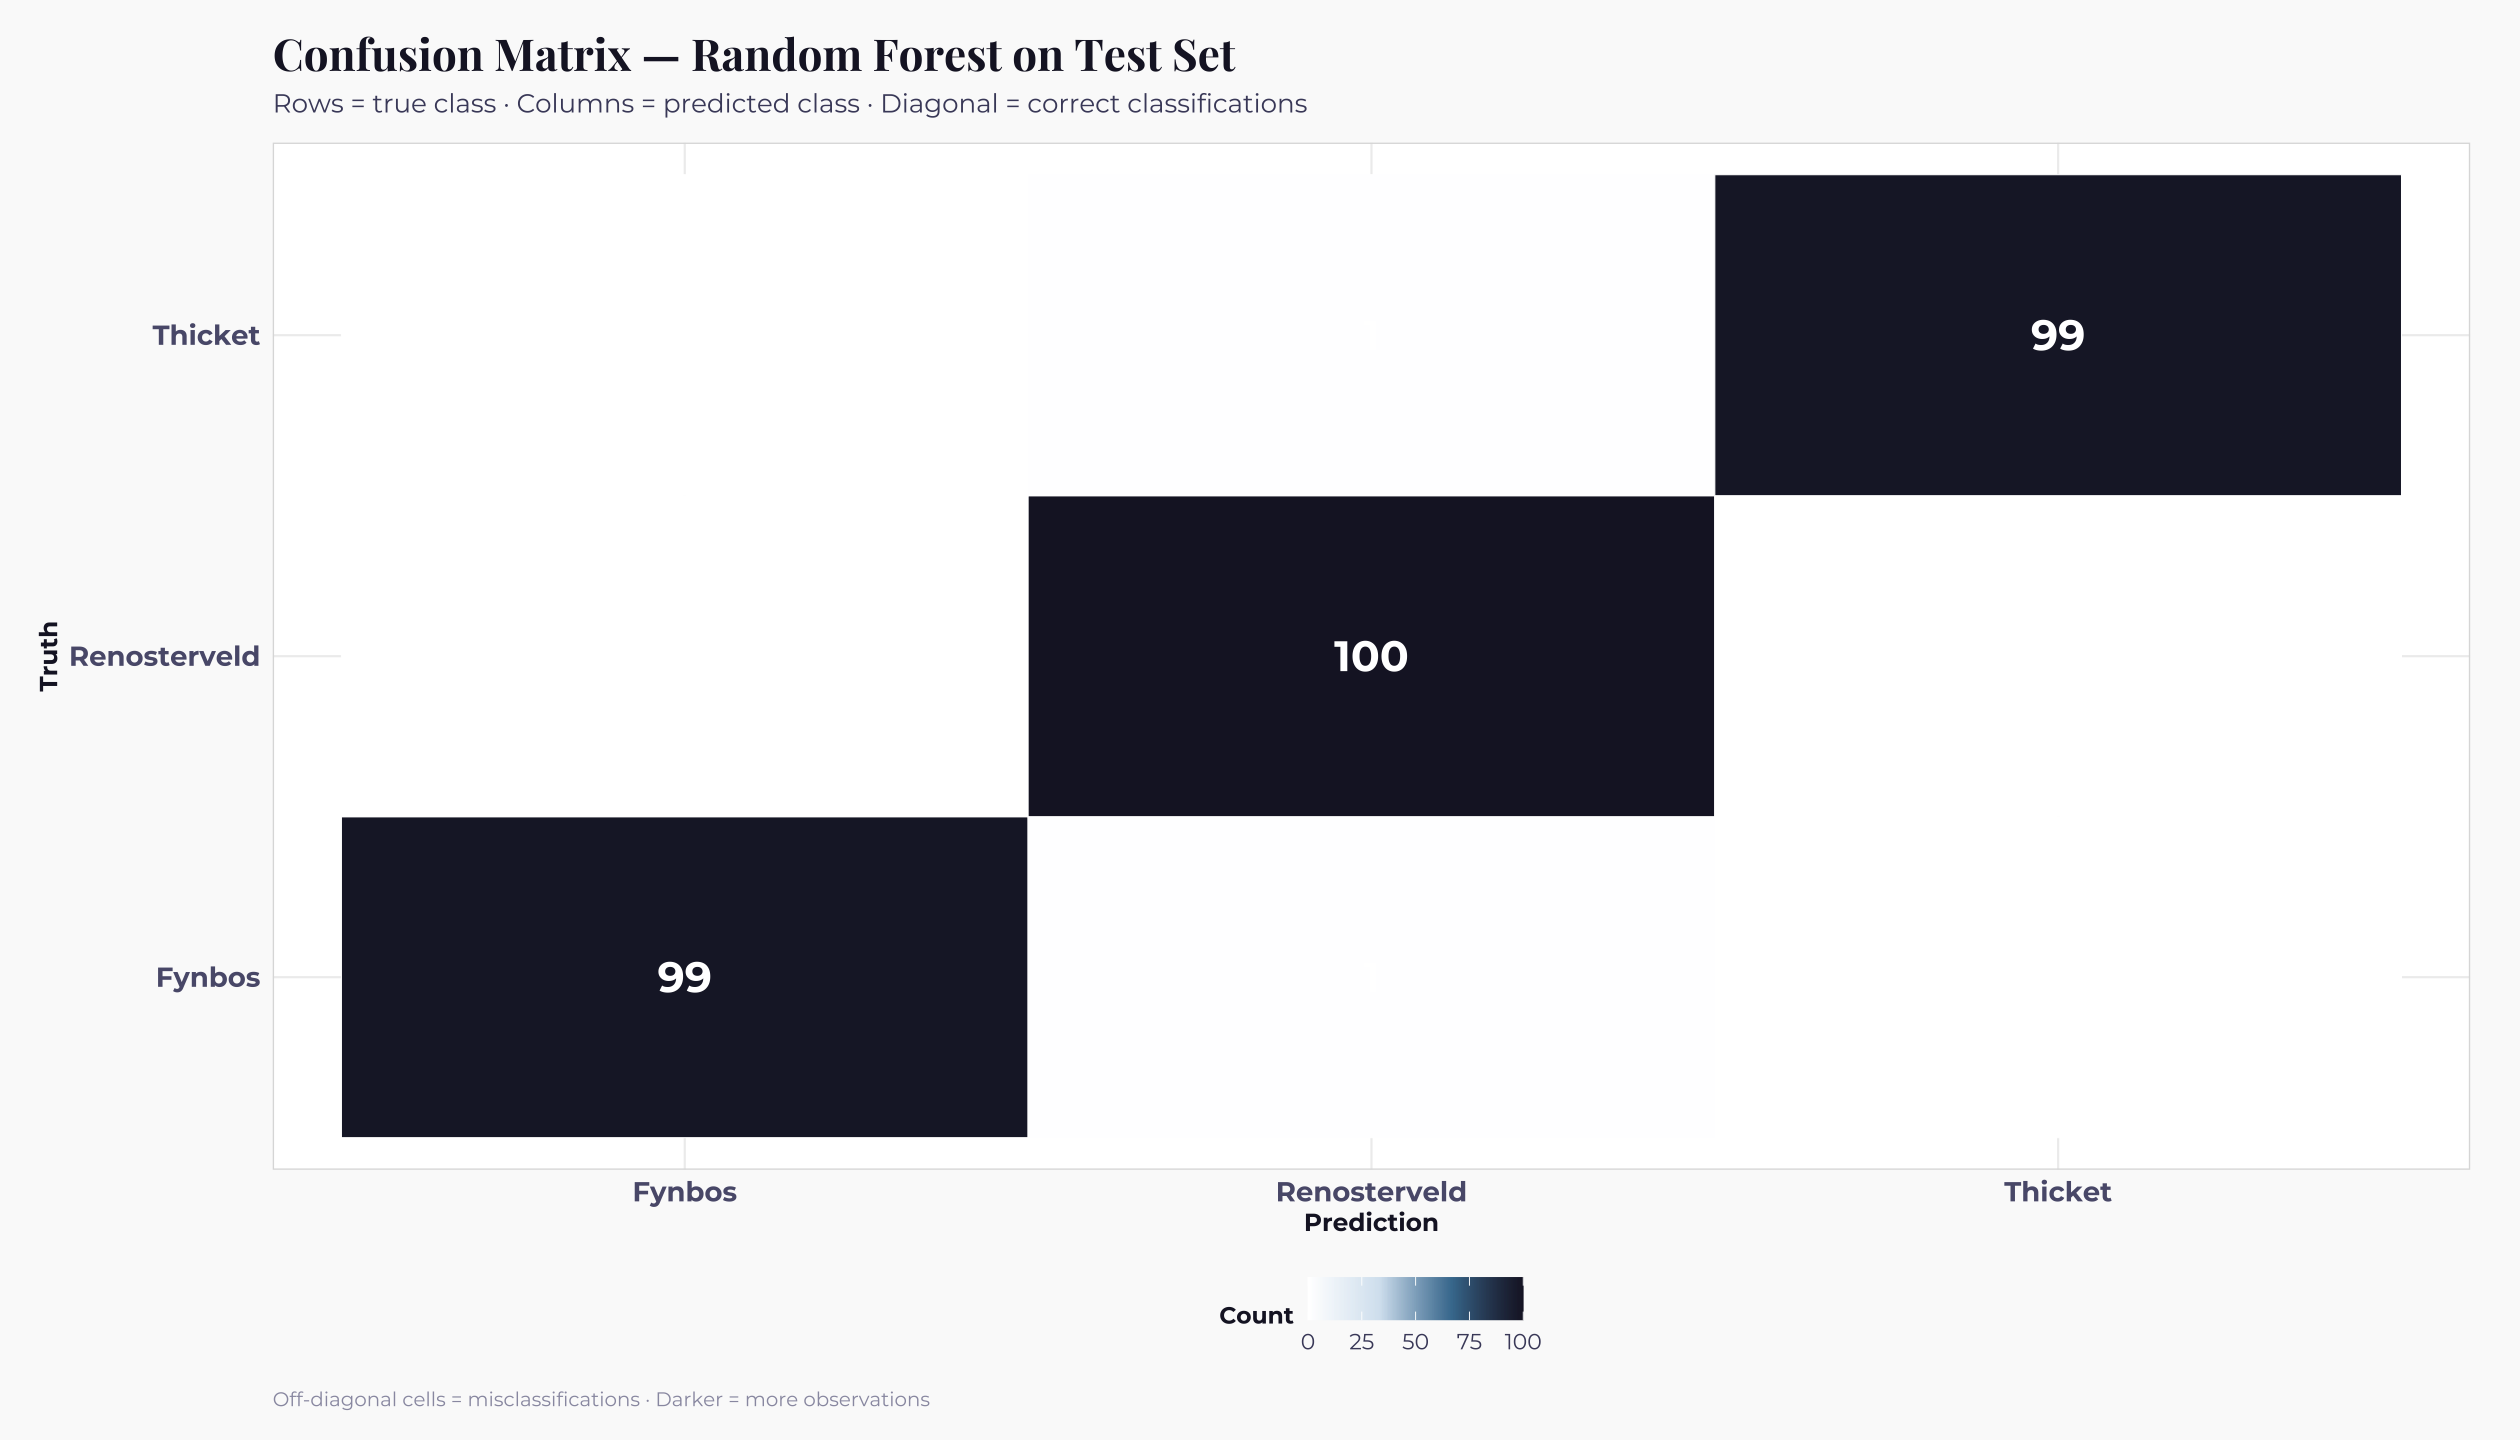

In [133]:
print(PCM)

#### Per-class metrics

In [134]:
PerClass <- TestPreds %>%
  group_by(vegetation) %>%
  summarise(
    n         = n(),
    .groups   = "drop"
  )

ClassMetrics <- bind_rows(
  precision(TestPreds, truth = vegetation, estimate = .pred_class),
  recall(TestPreds,    truth = vegetation, estimate = .pred_class),
  f_meas(TestPreds,    truth = vegetation, estimate = .pred_class)
) %>%
  rename(class = .estimator) %>%
  mutate(.metric = recode(.metric,
    "precision" = "Precision",
    "recall"    = "Recall",
    "f_meas"    = "F1 Score"
  ))

In [135]:
# Overall metrics for annotation
OverallAcc <- TestMetrics %>%
  filter(.metric == "accuracy") %>%
  pull(.estimate) %>%
  round(4)

OverallKap <- TestMetrics %>%
  filter(.metric == "kap") %>%
  pull(.estimate) %>%
  round(4)

In [136]:
# Per-class bar chart
ClassMetricsByClass <- TestPreds %>%
  group_by(vegetation) %>%
  summarise(
    Precision = sum(.pred_class == vegetation) /
                sum(.pred_class == vegetation | .pred_class != vegetation),
    .groups   = "drop"
  )

In [137]:
# Per-class bar chart
ClassMetricsByClass <- TestPreds %>%
  group_by(vegetation) %>%
  summarise(
    Precision = sum(.pred_class == vegetation) /
                sum(.pred_class == vegetation | .pred_class != vegetation),
    .groups   = "drop"
  )

In [138]:
PMetrics <- ggplot(PMets, aes(x = .metric, y = .estimate, fill = .metric)) +
  geom_col(width = 0.55, colour = "white") +
  geom_text(aes(label = round(.estimate, 3)),
            vjust = -0.4, family = "mont",
            fontface = "bold", size = 4.5, colour = "#1a1a2e") +
  scale_fill_manual(values = PalDiscrete[c(2,3,4)], guide = "none") +
  scale_y_continuous(limits = c(0, 1.05), labels = label_percent()) +
  annotate("text", x = 3.4, y = 0.95,
           label = paste0("Overall Accuracy: ", round(OverallAcc*100,1), "%\n",
                          "Kappa: ", round(OverallKap, 3)),
           family = "mont", size = 3.8, hjust = 1,
           colour = "#1a1a2e", fontface = "bold") +
  labs(
    title    = "Model Performance Metrics — Test Set",
    subtitle = "Weighted average across all three vegetation classes",
    x        = NULL, y        = "Score",
    caption  = "Precision = correctness of positive predictions · Recall = completeness · F1 = harmonic mean"
  ) +
  theme_ml()

In [139]:
# ROC curves
PROCS <- TestPreds %>%
  select(vegetation, starts_with(".pred_"), -.pred_class) %>%
  pivot_longer(starts_with(".pred_"),
               names_to  = "class",
               values_to = "prob") %>%
  mutate(
    class    = str_remove(class, "\\.pred_"),
    is_class = factor(as.character(vegetation) == class,
                      levels = c("TRUE", "FALSE"))
  ) %>%
  group_by(class) %>%
  roc_curve(truth = is_class, prob) %>%   # ← positional, no estimate =
  ggplot(aes(x = 1 - specificity, y = sensitivity, colour = class)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed",
              colour = "grey70", linewidth = 0.7) +
  geom_line(linewidth = 1.3) +
  scale_colour_manual(values = PalDiscrete[1:3], name = "Vegetation Class") +
  scale_x_continuous(labels = label_percent()) +
  scale_y_continuous(labels = label_percent()) +
  labs(
    title    = "ROC Curves by Class",
    subtitle = "One-vs-rest ROC · Closer to top-left corner = better discrimination",
    x        = "False Positive Rate (1 - Specificity)",
    y        = "True Positive Rate (Sensitivity)"
  ) +
  theme_ml()

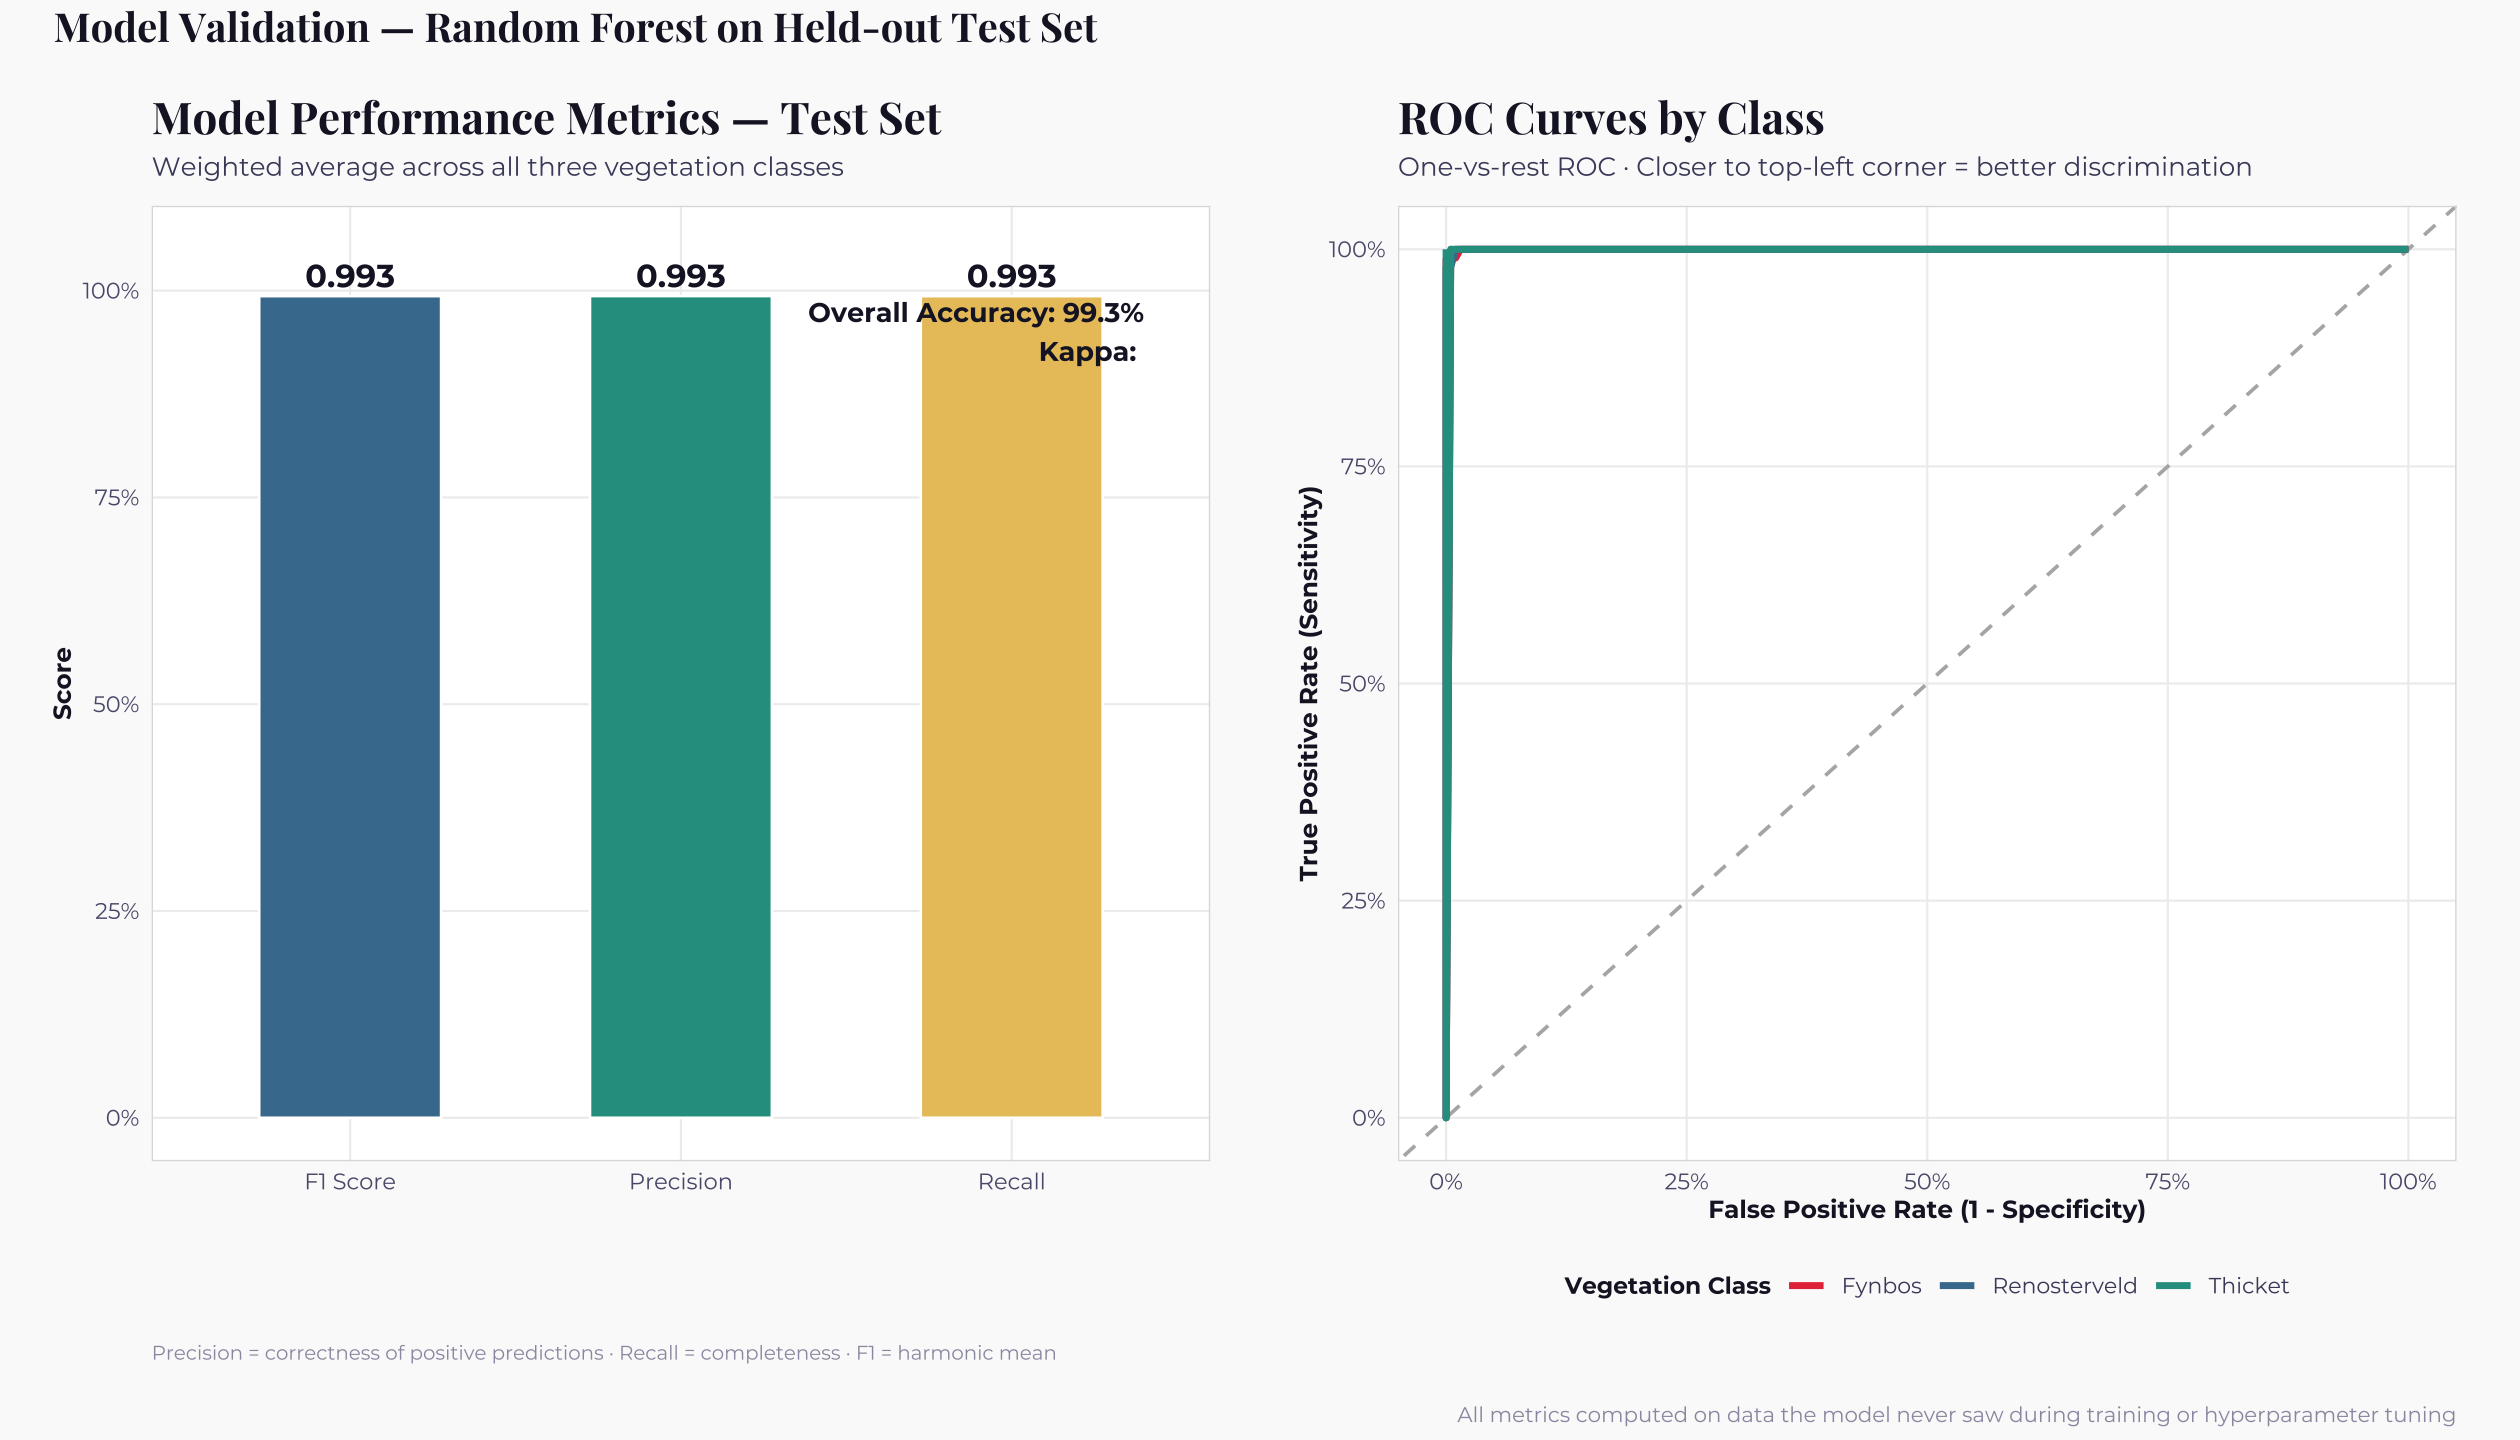

In [140]:
(PMetrics | PROCS) +
  plot_annotation(
    title   = "Model Validation — Random Forest on Held-out Test Set",
    caption = "All metrics computed on data the model never saw during training or hyperparameter tuning",
    theme   = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e"),
      plot.caption    = element_text(family = "mont", size = 8.5,
                                     colour = "#9a9ab0")
    )
  )

#### Variable importance

Which features matter most to the Random Forest?

In [141]:
FinalModel <- extract_fit_parsnip(FinalFit)

In [142]:
VIPData <- FinalModel$fit$variable.importance %>%
  enframe(name = "feature", value = "importance") %>%
  arrange(desc(importance)) %>%
  mutate(
    feature   = recode(feature,
      "ndvi"       = "NDVI",
      "band_swir"  = "SWIR Reflectance",
      "band_nir"   = "NIR Reflectance",
      "red_edge"   = "Red-Edge",
      "elevation"  = "Elevation",
      "slope"      = "Slope",
      "aspect_n"   = "Aspect (Northness)",
      "mean_precip" = "Mean Precipitation",
      "summer_temp" = "Summer Temperature"
    ),
    feature   = fct_reorder(feature, importance),
    category  = case_when(
      feature %in% c("NDVI","SWIR Reflectance","NIR Reflectance","Red-Edge") ~ "Spectral",
      feature %in% c("Elevation","Slope","Aspect (Northness)")               ~ "Topographic",
      TRUE                                                                    ~ "Climatic"
    )
  )

In [143]:
PVIP <- ggplot(VIPData, aes(x = feature, y = importance, fill = category)) +
  geom_col(width = 0.65, colour = "white") +
  geom_text(aes(label = round(importance, 0)),
            hjust = -0.15, family = "mont", size = 3.5, colour = "#1a1a2e") +
  coord_flip() +
  scale_fill_manual(
    values = c("Spectral"    = PalDiscrete[2],
               "Topographic" = PalDiscrete[3],
               "Climatic"    = PalDiscrete[4]),
    name   = "Feature Type"
  ) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.18))) +
  labs(
    title    = "Variable Importance — Random Forest",
    subtitle = "Mean decrease in node impurity across all trees · Higher = more important",
    x        = NULL, y = "Importance Score",
    caption  = "Spectral features dominate — consistent with remote sensing literature · Climate features provide secondary discrimination"
  ) +
  theme_ml()

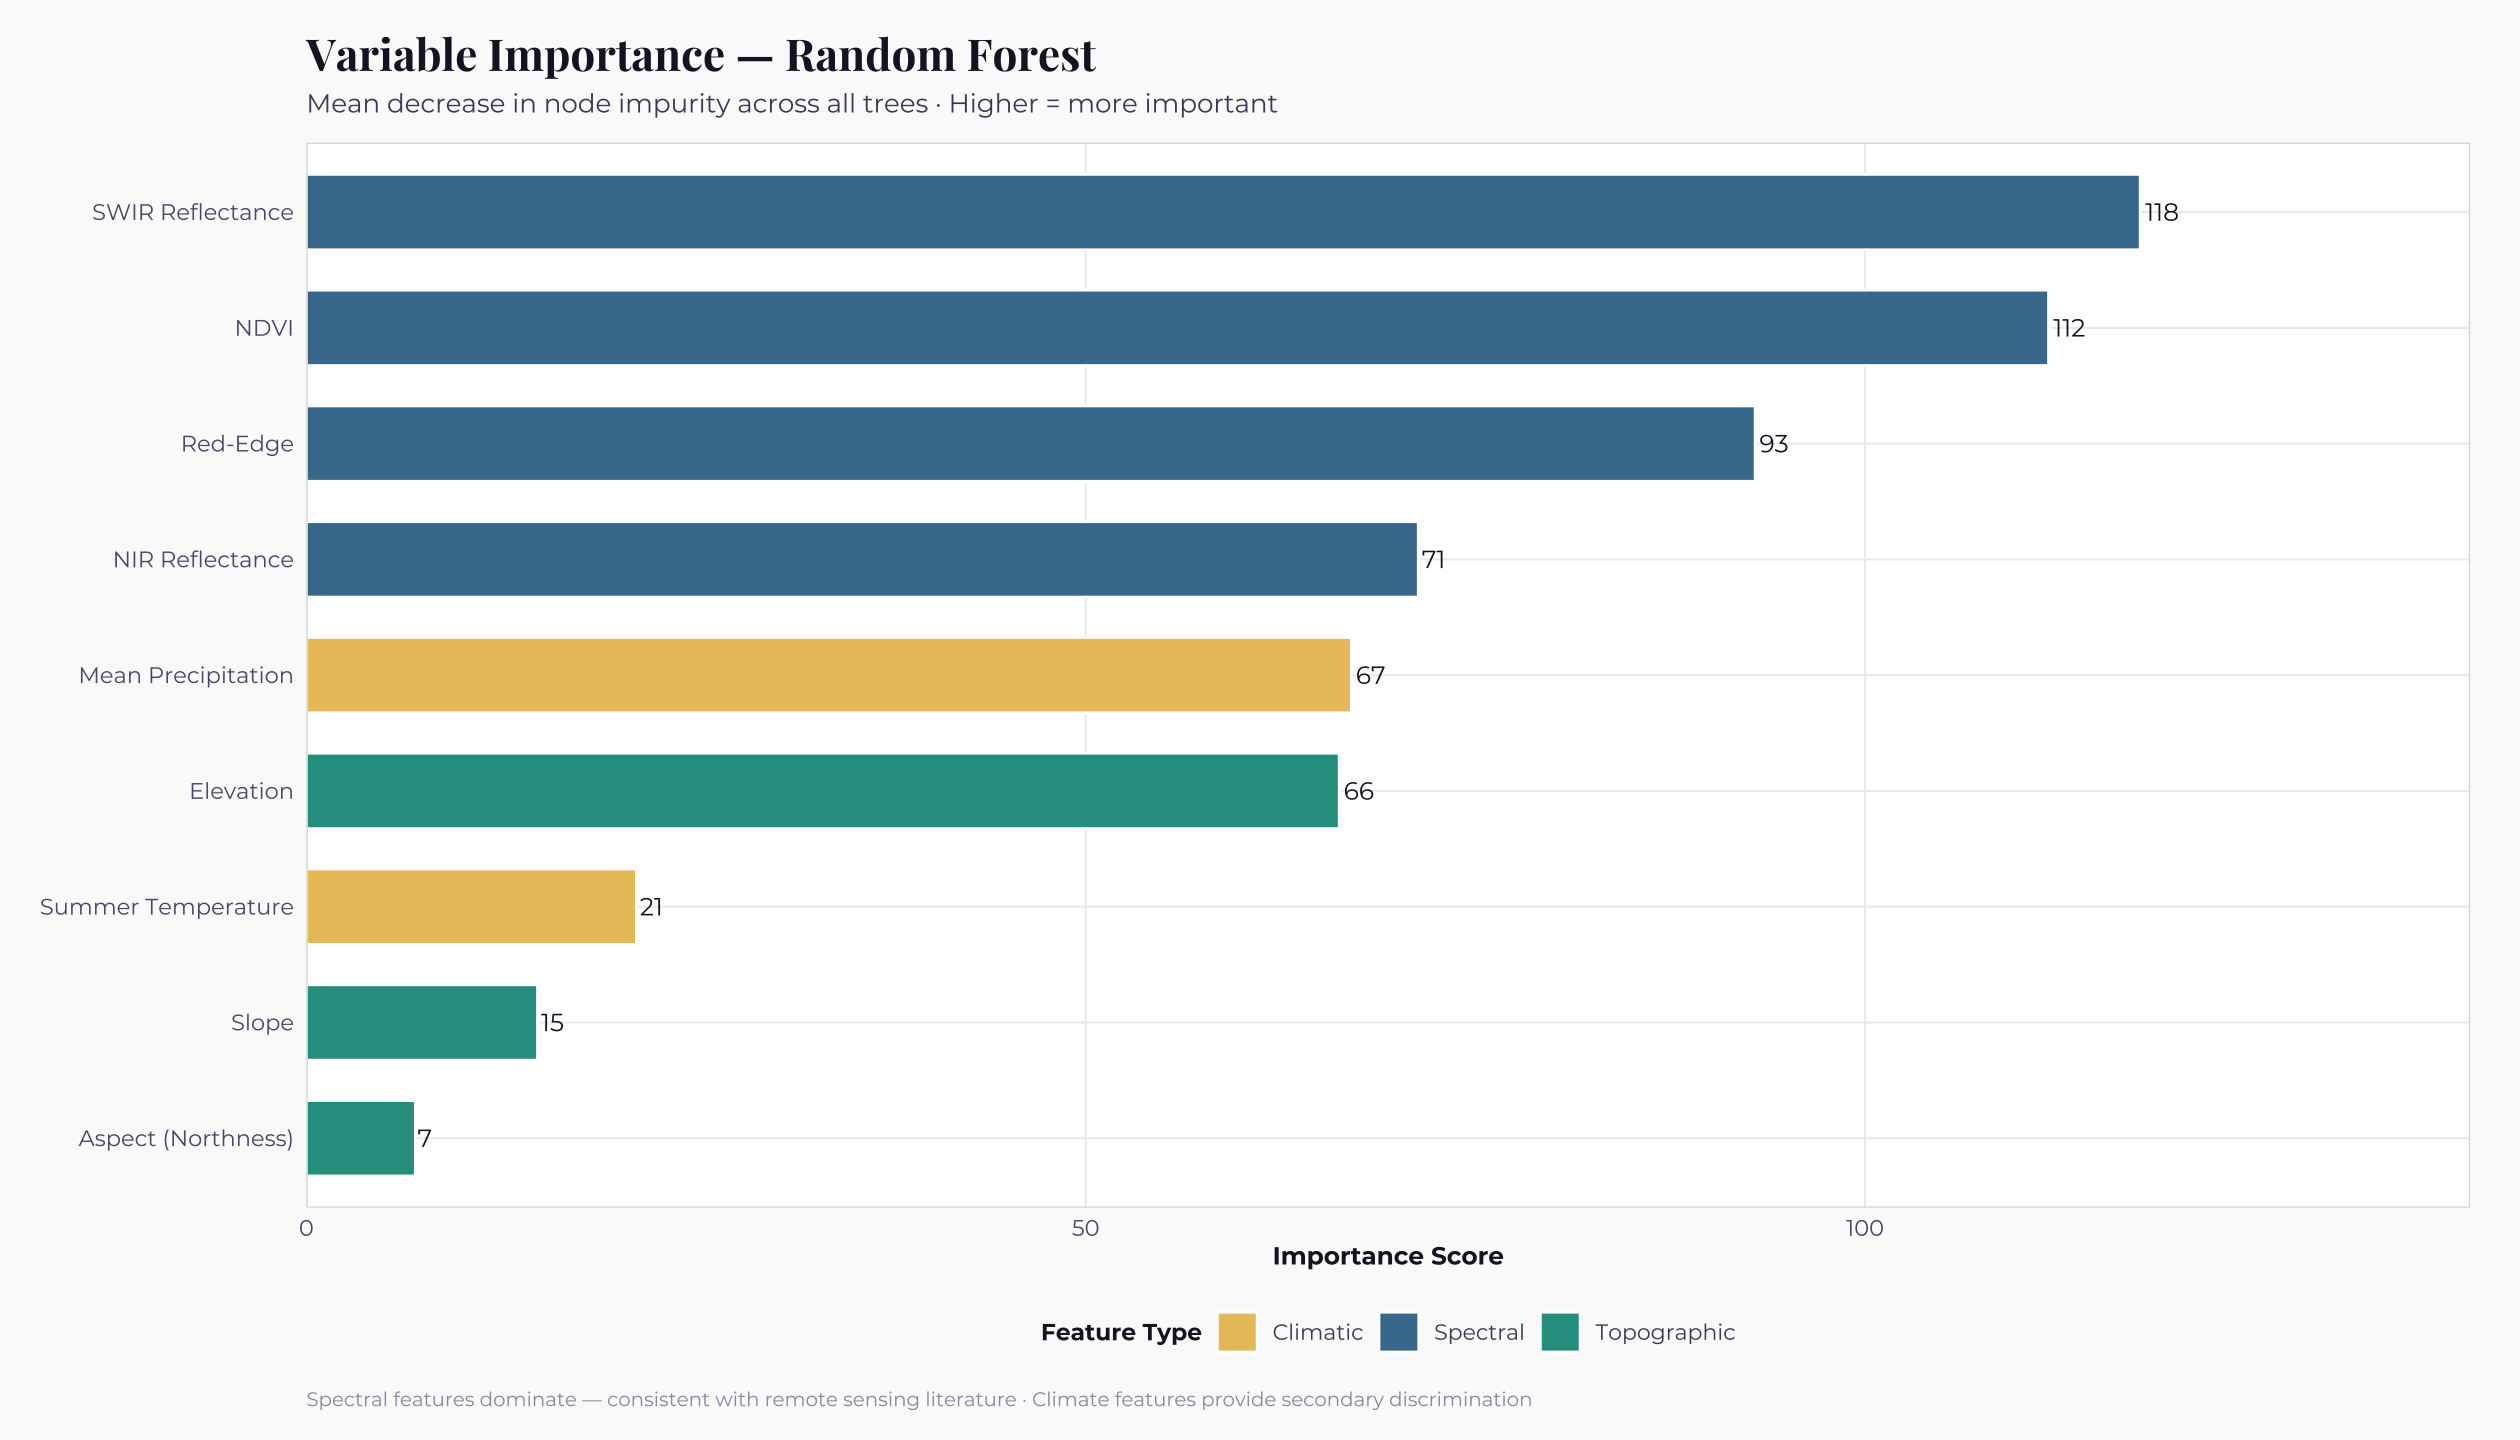

In [144]:
print(PVIP)

## 8 · Unsupervised Learning — K-Means Clustering

When you have no labels, unsupervised learning discovers natural groupings in your data. In remote sensing this is used for **spectral clustering** — grouping pixels by their spectral similarity before assigning ecological meaning to each cluster.

### Choosing the number of clusters k

The hardest problem in k-means is selecting k. We use two diagnostic tools:

- **Elbow method** — plot within-cluster sum of squares vs k and look for the elbow
- **Silhouette analysis** — measures how well each point fits its assigned cluster

### K-means spectral clustering

In [145]:
set.seed(2024)

# Use only spectral features for clustering — as in real remote sensing
SpectralData <- EcoData %>%
  select(ndvi, band_swir, band_nir, red_edge) %>%
  scale() %>%
  as_tibble()

In [146]:
# Elbow method — WSS across k = 1:10
WSSData <- map_dbl(1:10, function(k) {
  kmeans(SpectralData, centers = k, nstart = 20)$tot.withinss
})

ElbowDF <- tibble(k = 1:10, wss = WSSData)

In [147]:
PElbow <- ggplot(ElbowDF, aes(x = k, y = wss)) +
  geom_line(colour = PalDiscrete[2], linewidth = 1.2) +
  geom_point(size = 3.5, colour = PalDiscrete[2]) +
  geom_point(data = ElbowDF %>% filter(k == 3),
             size = 6, colour = PalDiscrete[1], shape = 21,
             fill = NA, stroke = 2) +
  annotate("label", x = 3.3, y = WSSData[3] + 50,
           label = "Elbow at k=3", fill = PalDiscrete[1],
           colour = "white", family = "mont", size = 3.5,
           label.padding = unit(0.3,"lines"), label.size = 0) +
  scale_x_continuous(breaks = 1:10) +
  labs(
    title    = "Elbow Method for Optimal k",
    subtitle = "Look for the point where adding more clusters gives diminishing returns",
    x        = "Number of Clusters (k)",
    y        = "Total Within-Cluster Sum of Squares",
    caption  = "The 'elbow' at k=3 matches our three true vegetation classes"
  ) +
  theme_ml()

Warning message in annotate("label", x = 3.3, y = WSSData[3] + 50, label = "Elbow at k=3", :
“Ignoring unknown parameters: `label.size`”


In [149]:
# Silhouette analysis
SilData <- map_dbl(2:10, function(k) {
  km <- kmeans(SpectralData, centers = k, nstart = 20)
  ss <- silhouette(km$cluster, dist(SpectralData))
  mean(ss[, 3])
})

SilDF <- tibble(k = 2:10, sil = SilData)

Warning message:
“did not converge in 10 iterations”


In [150]:
PSil <- ggplot(SilDF, aes(x = k, y = sil)) +
  geom_line(colour = PalDiscrete[3], linewidth = 1.2) +
  geom_point(size = 3.5, colour = PalDiscrete[3]) +
  geom_point(data = SilDF %>% slice_max(sil, n=1),
             size = 6, colour = PalDiscrete[1], shape = 21,
             fill = NA, stroke = 2) +
  scale_x_continuous(breaks = 2:10) +
  labs(
    title    = "Silhouette Analysis",
    subtitle = "Higher = better cluster cohesion and separation",
    x        = "Number of Clusters (k)",
    y        = "Mean Silhouette Score",
    caption  = "Peak silhouette score confirms optimal k"
  ) +
  theme_ml()

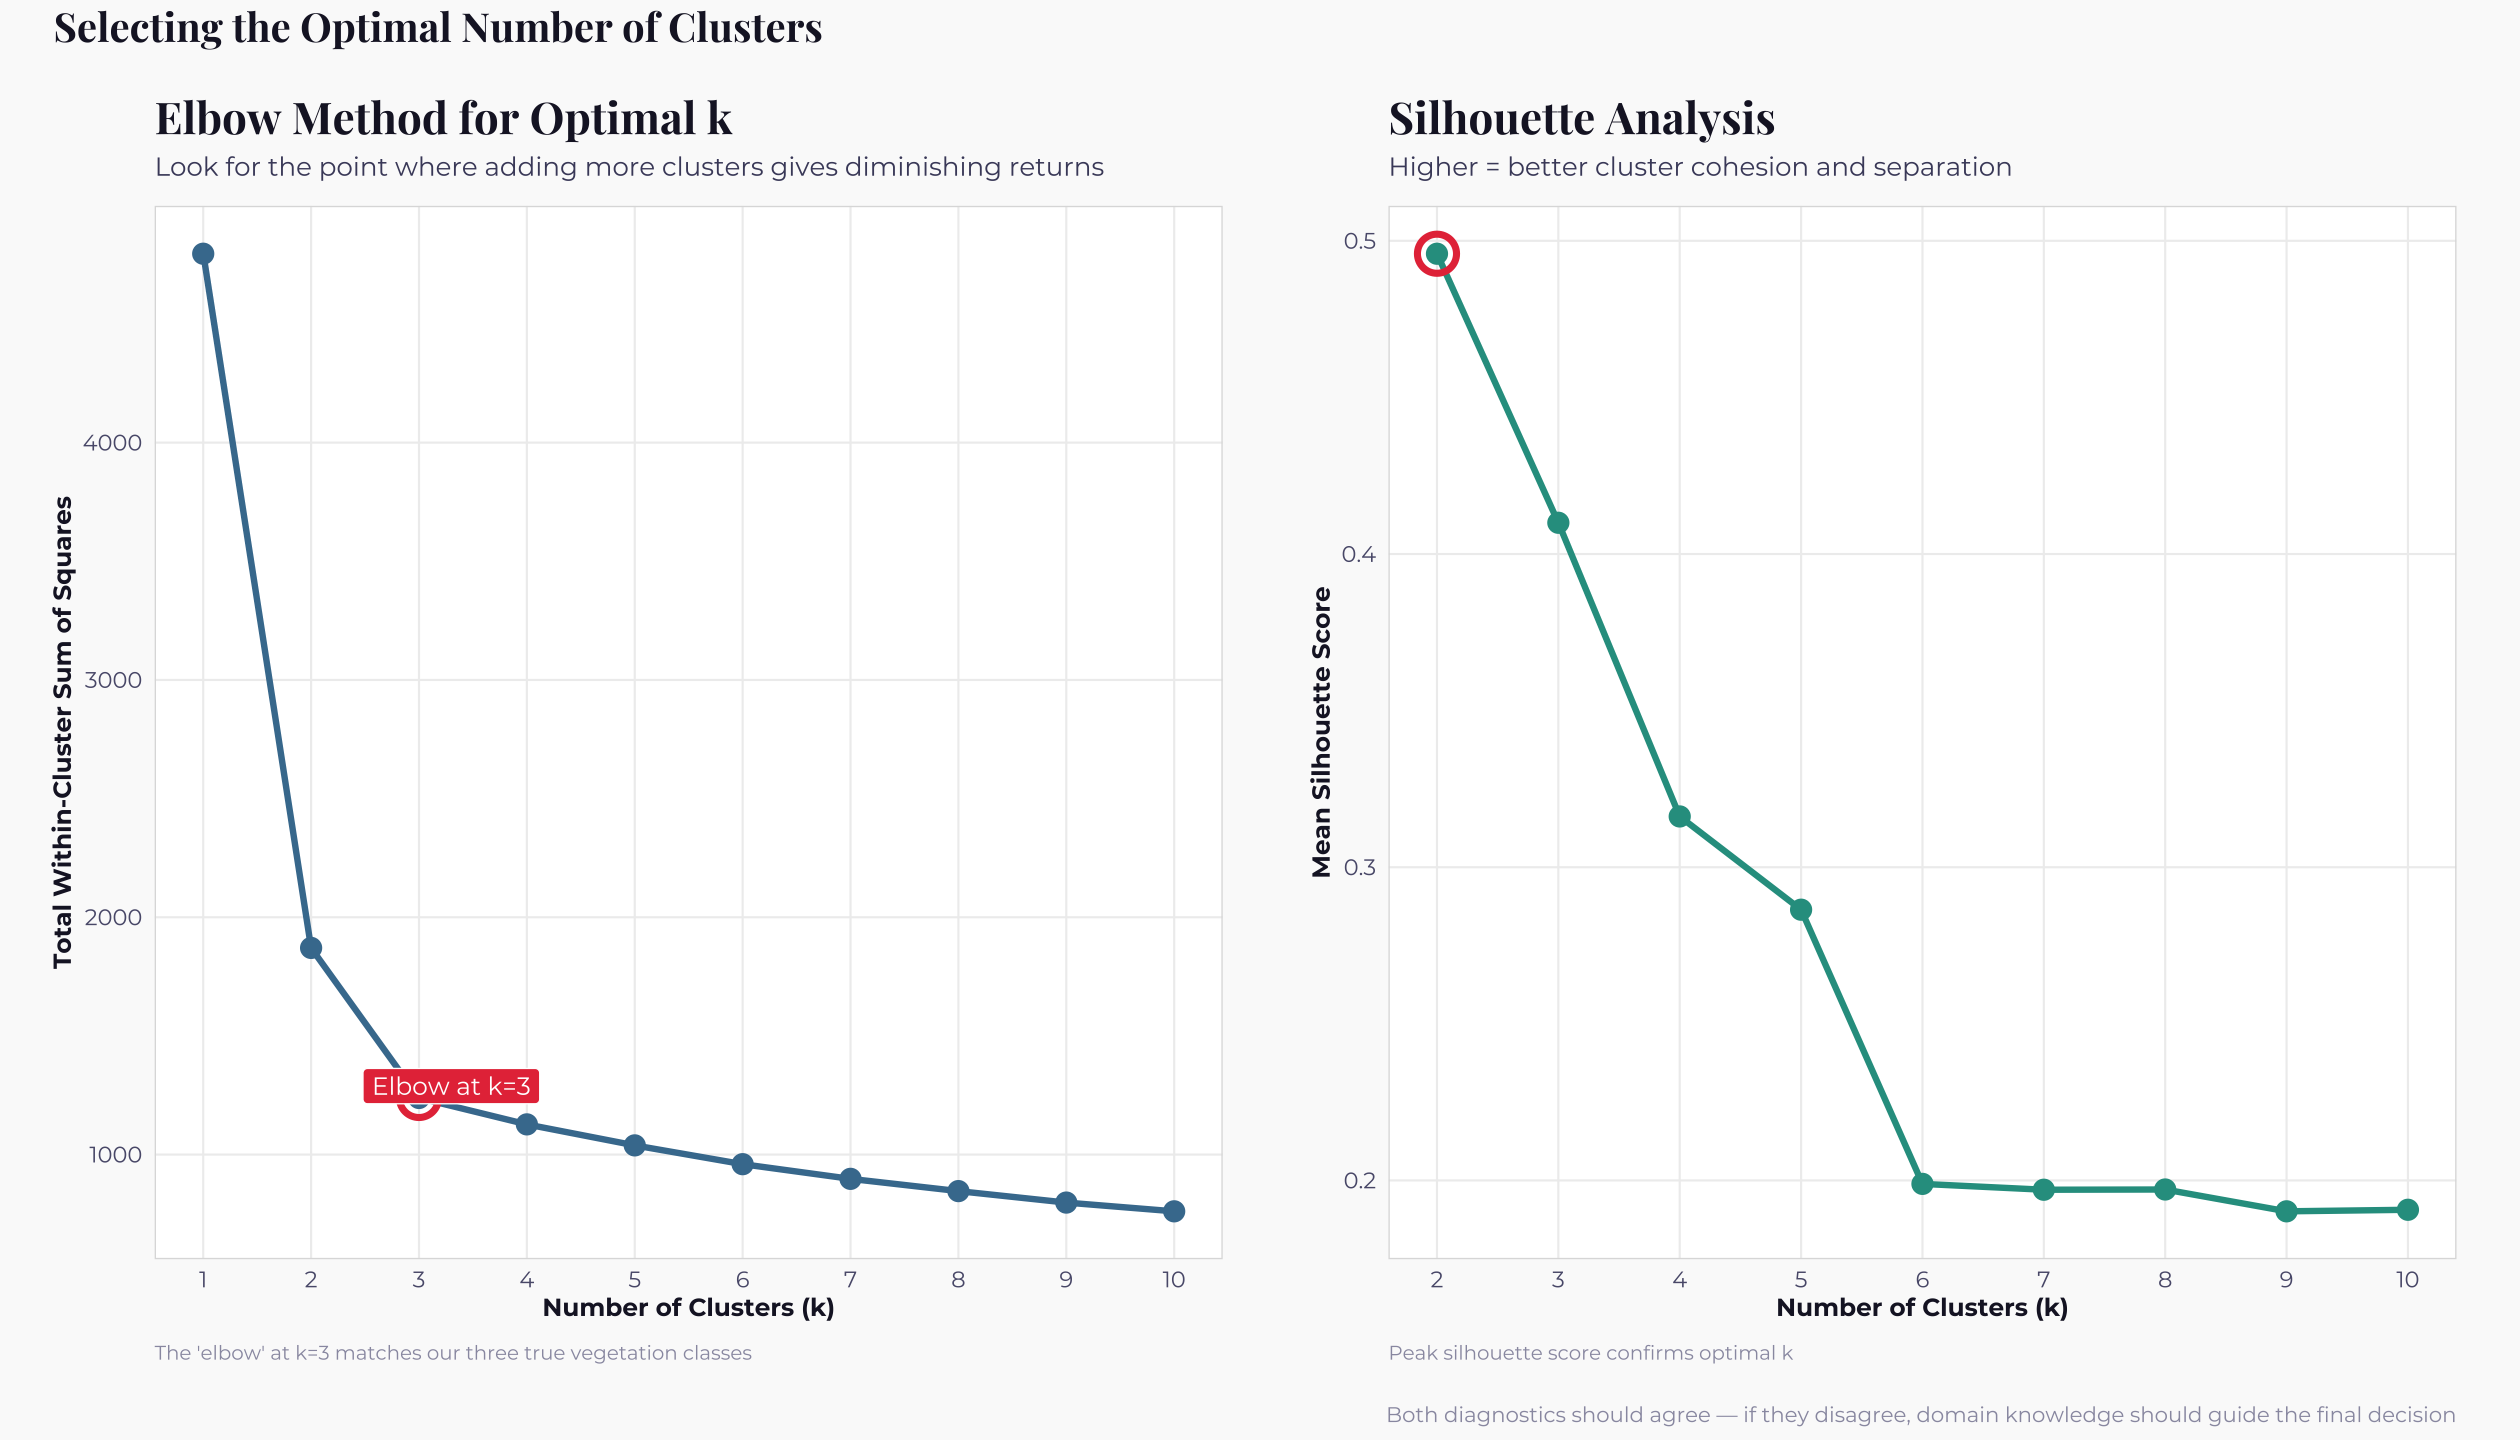

In [151]:
(PElbow | PSil) +
  plot_annotation(
    title   = "Selecting the Optimal Number of Clusters",
    caption = "Both diagnostics should agree — if they disagree, domain knowledge should guide the final decision",
    theme   = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e"),
      plot.caption    = element_text(family = "mont", size = 8.5,
                                     colour = "#9a9ab0")
    )
  )

#### Fit final k-means and visualise clusters

In [152]:
set.seed(2024)
KM_Final <- kmeans(SpectralData, centers = 3, nstart = 50)

In [153]:
ClusterDF <- EcoData %>%
  mutate(
    cluster   = factor(KM_Final$cluster,
                       labels = paste("Cluster", 1:3)),
    true_class = vegetation
  )

In [154]:
# Cluster composition — how well do clusters match true classes?
CompTable <- ClusterDF %>%
  count(cluster, true_class) %>%
  group_by(cluster) %>%
  mutate(pct = n / sum(n) * 100)

In [155]:
PComp <- ggplot(CompTable, aes(x = cluster, y = pct, fill = true_class)) +
  geom_col(width = 0.65, colour = "white") +
  geom_text(aes(label = paste0(round(pct), "%")),
            position = position_stack(vjust = 0.5),
            family = "mont", size = 3.5, colour = "white", fontface = "bold") +
  scale_fill_manual(values = PalDiscrete[1:3], name = "True Vegetation Class") +
  scale_y_continuous(labels = label_percent(scale = 1)) +
  labs(
    title    = "Cluster Composition vs True Classes",
    subtitle = "How purely does each spectral cluster correspond to a vegetation type?",
    x        = NULL, y = "Percentage of Cluster",
    caption  = "High purity = good spectral separability · Mixed clusters = spectral overlap between classes"
  ) +
  theme_ml()

In [156]:
# Cluster profiles — mean spectral signature per cluster
CentreDF <- as_tibble(KM_Final$centers) %>%
  mutate(cluster = paste("Cluster", 1:3)) %>%
  pivot_longer(-cluster, names_to = "feature", values_to = "value") %>%
  mutate(feature = recode(feature,
    "ndvi"      = "NDVI",
    "band_swir" = "SWIR",
    "band_nir"  = "NIR",
    "red_edge"  = "Red-Edge"
  ))

In [157]:
PProfile <- ggplot(CentreDF, aes(x = feature, y = value,
                                  colour = cluster, group = cluster)) +
  geom_hline(yintercept = 0, colour = "grey80", linewidth = 0.5) +
  geom_line(linewidth = 1.3) +
  geom_point(size = 4) +
  scale_colour_manual(values = PalDiscrete[1:3], name = "Cluster") +
  labs(
    title    = "Spectral Profiles of Each Cluster",
    subtitle = "Standardised mean feature values per cluster centroid",
    x        = "Spectral Feature", y = "Standardised Value",
    caption  = "Diverging profiles = well-separated clusters · Converging profiles = difficult discrimination"
  ) +
  theme_ml()

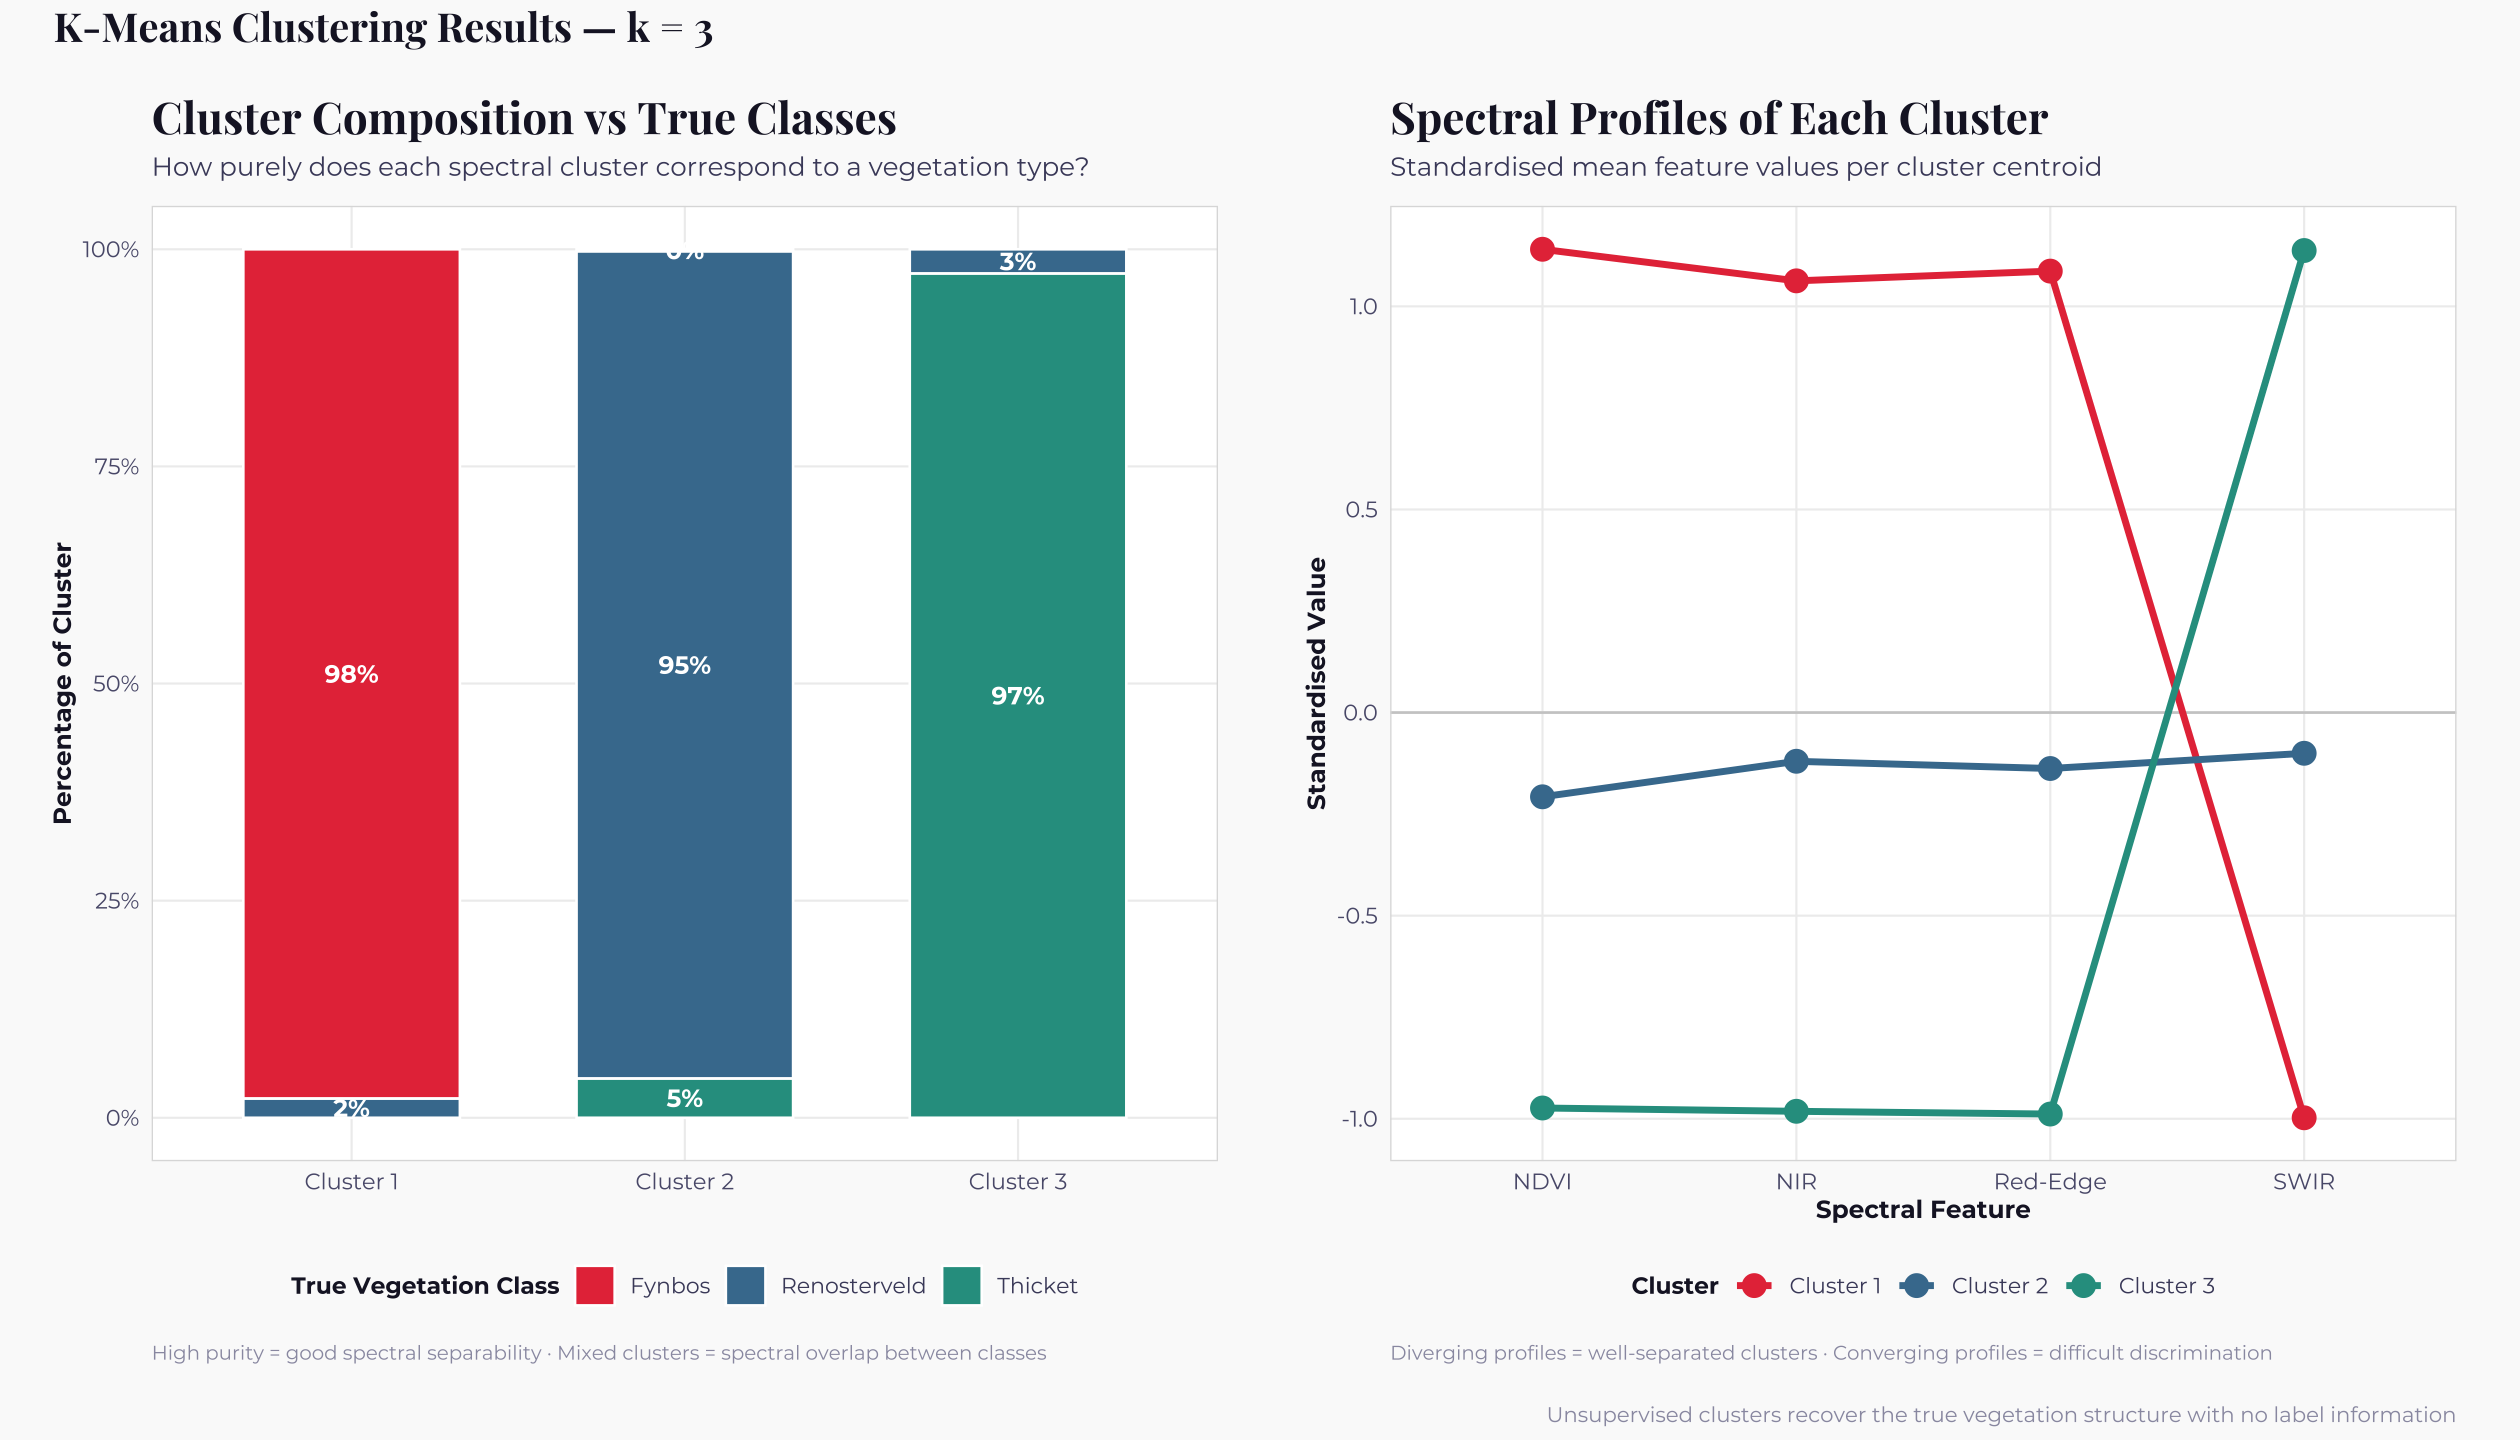

In [158]:
(PComp | PProfile) +
  plot_annotation(
    title   = "K-Means Clustering Results — k = 3",
    caption = "Unsupervised clusters recover the true vegetation structure with no label information",
    theme   = theme(
      plot.background = element_rect(fill = "#fafafa", colour = NA),
      plot.title      = element_text(family = "playfair", face = "bold",
                                     size = 16, colour = "#1a1a2e"),
      plot.caption    = element_text(family = "mont", size = 8.5,
                                     colour = "#9a9ab0")
    )
  )

This marks the end of Introduction to Machine learning

### What comes next in spatial ML:

- **Spatial cross-validation** — accounting for spatial autocorrelation in train/test splits
- **Transfer learning** — applying models trained in one area to a new area
- **Deep learning for imagery** — CNNs for object detection and semantic segmentation
- **Time series ML** — change detection and phenology from multi-temporal data
- **Uncertainty quantification** — knowing when the model does not know